<a href="https://colab.research.google.com/github/Yolanda2727/MODELO-IA/blob/main/Nuevo_articulo_Genomic_Governance_Traceability_Colab_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instrucciones de Uso

Este notebook reproduce los análisis, tablas de trazabilidad y figuras de alta resolución documentados en las matrices de evidencia suplementarias.

### Para comenzar:

1.  **Cargar Archivos:** Ejecuta la celda en la sección "1. Upload or mount files" para cargar el archivo Excel `Review_Evidence_Master_Matrix_v1.1_corrected.xlsx`. Si ya está cargado, no es necesario volver a hacerlo.
2.  **Escribir Script de Pipeline:** Ejecuta la celda en la sección "2. Write the pipeline script" para crear el archivo `genomic_governance_traceability_pipeline.py`.
3.  **Ejecutar Pipeline:** Ejecuta la celda en la sección "3. Run the pipeline" para ejecutar el script y generar los resultados y figuras.
4.  **Inspeccionar y Descargar:** Las secciones restantes te permitirán inspeccionar el manifiesto de resultados y descargar un archivo ZIP con todas las salidas generadas.

Las celdas subsiguientes realizan análisis y visualizaciones adicionales de los datos, como redes de co-ocurrencia, mapas de calor de conceptos y categorías, y análisis de significancia estadística. Puedes ejecutar estas celdas secuencialmente para explorar los resultados.

# Genomic Governance Framework — Google Colab Traceability Pipeline

This notebook reproduces the documented descriptive analyses, traceability tables, and high-resolution figures from the supplementary evidence matrices.

**Scientific safeguards**

- It does not invent PRISMA counts, localizers, kappa values, effect sizes, p-values, forest plots, funnel plots, or heterogeneity statistics.
- It treats the documented 42-source set as a development / documented analytic set, not as field-wide prevalence.
- It exports a SHA-256 manifest for all inputs and outputs.


## 1. Upload or mount files
Upload the evidence matrix and optional audit matrices.

In [39]:
# Option A: upload files manually
from google.colab import files
uploaded = files.upload()

# Option B: mount Google Drive instead
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.environ['DATA_DIR'] = '/content/drive/MyDrive/genomic_governance_project'
# os.environ['OUTPUT_DIR'] = '/content/drive/MyDrive/genomic_governance_project/outputs_traceability'


Saving Review_Evidence_Master_Matrix_v1.1_corrected.xlsx to Review_Evidence_Master_Matrix_v1.1_corrected (1).xlsx


## 2. Write the pipeline script

In [79]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import shutil
import zipfile
from datetime import datetime, timezone
from itertools import combinations
from pathlib import Path
from typing import Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import networkx as nx # Added for network graph visualization
import seaborn as sns # Added for correlation scatter plots
from scipy.stats import fisher_exact # Added for p-value calculation


PIPELINE_VERSION = "1.0"
UTC_NOW = lambda: datetime.now(timezone.utc).replace(microsecond=0).isoformat()


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

EXPECTED_FILES = {
    "evidence": [
        "Review_Evidence_Master_Matrix_v1.1_corrected.xlsx",
        "Review_Evidence_Master_Matrix_v1.0.xlsx",
    ],
    "claim_citation": [
        "Fase_06_v3.0_matriz_afirmacion_fuente_citas.xlsx",
        "Fase_06_v2.0_auditoria_Vancouver_trazabilidad.xlsx",
    ],
    "analysis_plan": [
        "Fase_07_v3.0_matriz_ejecucion_analitica.xlsx",
        "High_Level_Analytical_Adjudication_Matrix_v1.0.xlsx",
    ],
    "prisma_audit": [
        "Fase_12_v2.0_Auditoria_PRISMA_ScR_PRISMA_S.xlsx",
        "Submission_Closure_Package_v2.0.xlsx",
    ],
}

SHEET_NAMES = {
    "article_evidence": "01_Article_Evidence",
    "excluded_records": "02_Excluded_Records",
    "result_claims": "03_Result_Claims",
    "concept_matrix": "04_Concept_Matrix",
    "concept_overlap": "05_Concept_Overlap",
    "emergent_categories": "06_Emergent_Categories",
    "source_profile": "07_Source_Profile",
    "rights_duties_remedies": "08_Rights_Duties_Remedies",
}

CONCEPT_COLUMNS = {
    "AGP": "Algorithmic genomic biopower",
    "CGS": "Conditional genomic sovereignty",
    "AD": "Anticipatory dignity",
    "MGJ": "Multilevel genomic justice",
}

CATEGORY_COLUMNS = {
    "Transparency/contestability": "Transparency, accountability, or contestability",
    "Consent/secondary use": "Consent as process, secondary use, or reanalysis",
    "Context migration": "Cross-sector or transnational contextual migration",
    "Collective authority": "Collective authority, stewardship, or community governance",
    "Predictive identity": "Predictive identity, discrimination, or stigma",
    "Equity/access/capacity": "Equity, access, benefit sharing, or capacity",
    "Trust/commercialisation": "Trust, social licence, or commercialisation",
}

CATEGORY_COLUMNS_RENAMED = {
    'Transparency/contestability': 'Transparency, accountability, or contestability',
    'Consent/secondary use': 'Consent as process, secondary use, or reanalysis',
    'Context migration': 'Cross-sector or transnational contextual migration',
    'Collective authority': 'Collective authority, stewardship, or community governance',
    'Predictive identity': 'Predictive identity, discrimination, or stigma',
    'Equity/access/capacity': 'Equity, access, benefit sharing, or capacity',
    'Trust/commercialisation': 'Trust, social licence, or commercialisation',
}

SPLIT_YEAR = 2022


# ---------------------------------------------------------------------------
# Utility functions
# ---------------------------------------------------------------------------

def sha256_file(path: Path) -> str:
    """Return SHA-256 checksum for a file."""
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for block in iter(lambda: fh.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def find_existing_file(data_dir: Path, candidates: Sequence[str], required: bool = True) -> Optional[Path]:
    """Find the first existing file in candidates."""
    for name in candidates:
        path = data_dir / name
        if path.exists():
            return path
    if required:
        raise FileNotFoundError(
            "None of the expected files was found:\n"
            + "\n".join(str(data_dir / name) for name in candidates)
        )
    return None


def read_excel_sheet(path: Path, sheet: str) -> pd.DataFrame:
    """Read an Excel sheet and normalize column names minimally."""
    df = pd.read_excel(path, sheet_name=sheet, engine="openpyxl")
    df.columns = [str(c).strip() for c in df.columns]
    return df


def safe_int(series: pd.Series) -> pd.Series:
    """Convert a pandas Series to integer values, using 0 for missing."""
    return pd.to_numeric(series, errors="coerce").fillna(0).astype(int)


def ensure_columns(df: pd.DataFrame, required: Sequence[str], sheet_name: str) -> None:
    """Raise a clear error if required columns are missing."""
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Sheet {sheet_name!r} is missing required columns: {missing}")


def write_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")


def write_json(obj: object, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")

def rounded_box(ax, x, y, w, h, title, subtitle="", fontsize=8.5, dashed=False):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.010,rounding_size=0.012",
        linewidth=1.15,
        edgecolor="black",
        facecolor="white",
        linestyle="--" if dashed else "-",
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h * (0.60 if subtitle else 0.50),
        title,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
    )
    if subtitle:
        ax.text(
            x + w / 2,
            y + h * 0.26,
            subtitle,
            ha="center",
            va="center",
            fontsize=max(6.4, fontsize - 1.4),
        )
    return patch


def arrow(ax, x1, y1, x2, y2, lw=1.15):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=10,
            linewidth=lw,
            color="black",
        )
    )


# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------

def load_input_files(data_dir: Path) -> Dict[str, Optional[Path]]:
    files = {
        key: find_existing_file(data_dir, candidates, required=(key == "evidence"))
        for key, candidates in EXPECTED_FILES.items()
    }
    return files


def load_evidence_tables(evidence_path: Path) -> Dict[str, pd.DataFrame]:
    """Load the core sheets from the evidence master matrix."""
    tables = {}
    for key, sheet in SHEET_NAMES.items():
        try:
            tables[key] = read_excel_sheet(evidence_path, sheet)
        except Exception as exc:
            raise RuntimeError(f"Could not read required sheet {sheet!r} from {evidence_path}") from exc

    ensure_columns(
        tables["article_evidence"],
        ["Record", "Title", "Year", "Journal", "DOI", "PMID", "Sampling stratum"],
        "01_Article_Evidence",
    )
    ensure_columns(
        tables["concept_matrix"],
        ["Record", "AGP", "CGS", "AD", "MGJ"],
        "04_Concept_Matrix",
    )
    return tables


# ---------------------------------------------------------------------------
# Analysis
# ---------------------------------------------------------------------------

def compute_concept_counts(concept_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col, full_name in CONCEPT_COLUMNS.items():
        if col not in concept_df.columns:
            raise ValueError(f"Concept column {col!r} is missing from concept matrix.")
        n = int(safe_int(concept_df[col]).sum())
        rows.append({"concept_code": col, "concept": full_name, "n": n, "percent_of_42": n / len(concept_df)})
    return pd.DataFrame(rows)


def compute_category_counts(concept_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col, full_name in CATEGORY_COLUMNS.items():
        if col not in concept_df.columns:
            raise ValueError(f"Category column {col!r} is missing from concept matrix.")
        n = int(safe_int(concept_df[col]).sum())
        rows.append({"category_code": col, "category": full_name, "n": n, "percent_of_42": n / len(concept_df)})
    return pd.DataFrame(rows)


def compute_exact_patterns(concept_df: pd.DataFrame) -> pd.DataFrame:
    df = concept_df.copy()
    for col in CONCEPT_COLUMNS:
        df[col] = safe_int(df[col])
    def pattern(row):
        active = [c for c in CONCEPT_COLUMNS if row[c] == 1]
        return "+".join(active) if active else "None"
    df["pattern"] = df.apply(pattern, axis=1)
    out = (
        df.groupby("pattern", dropna=False)
        .size()
        .reset_index(name="n")
        .sort_values(["n", "pattern"], ascending=[False, True])
    )
    out["percent_of_42"] = out["n"] / len(df)
    return out


def compute_overlap(concept_df: pd.DataFrame) -> pd.DataFrame:
    df = concept_df.copy()
    for col in CONCEPT_COLUMNS:
        df[col] = safe_int(df[col])
    rows = []
    for a, b in combinations(CONCEPT_COLUMNS.keys(), 2):
        n_a = int(df[a].sum())
        n_b = int(df[b].sum())
        inter = int((df[a] * df[b]).sum())
        union = n_a + n_b - inter
        rows.append({
            "concept_a": a,
            "concept_b": b,
            "n_a": n_a,
            "n_b": n_b,
            "intersection": inter,
            "union": union,
            "jaccard": inter / union if union else np.nan,
            f"P({b}|{a})": inter / n_a if n_a else np.nan,
            f"P({a}|{b})": inter / n_b if n_b else np.nan,
        })
    return pd.DataFrame(rows)


def compute_concept_category_matrix(concept_df: pd.DataFrame) -> pd.DataFrame:
    df = concept_df.copy()
    for col in list(CONCEPT_COLUMNS) + list(CATEGORY_COLUMNS):
        if col in df.columns:
            df[col] = safe_int(df[col])
    mat = pd.DataFrame(index=list(CONCEPT_COLUMNS), columns=list(CATEGORY_COLUMNS), dtype=int)
    for c in CONCEPT_COLUMNS:
        for cat in CATEGORY_COLUMNS:
            mat.loc[c, cat] = int((df[c] * df[cat]).sum())
    mat.index.name = "concept"
    return mat

def compute_concept_category_matrix_for_period(df_period_original): # Renamed to avoid conflict
    df_period = df_period_original.copy()
    concept_cols = [col for col in CONCEPT_COLUMNS.keys() if col in df_period.columns]
    category_cols = [col for col in CATEGORY_COLUMNS.keys() if col in df_period.columns]

    for col in concept_cols + category_cols:
        df_period.loc[:, col] = df_period[col].fillna(0).astype(int)

    mat = pd.DataFrame(index=concept_cols, columns=category_cols, dtype=int)
    for c in concept_cols:
        for cat in category_cols:
            mat.loc[c, cat] = int((df_period[c] * df_period[cat]).sum())
    mat.index.name = 'concept'
    return mat

def compute_p_value_matrix_for_period(df_period_original, N_TOTAL_SOURCES_PERIOD):
    df_period = df_period_original.copy()
    concept_category_matrix_period = compute_concept_category_matrix_for_period(df_period)

    # Recalculate concept and category counts for this specific period
    concept_counts_period = {c: df_period[c].sum() for c in CONCEPT_COLUMNS.keys() if c in df_period.columns}
    category_counts_period = {c: df_period[c].sum() for c in CATEGORY_COLUMNS.keys() if c in df_period.columns}

    p_value_matrix_period = pd.DataFrame(index=concept_category_matrix_period.index,
                                         columns=concept_category_matrix_period.columns, dtype=float)

    for concept in concept_category_matrix_period.index:
        for category in concept_category_matrix_period.columns:
            a = concept_category_matrix_period.loc[concept, category]
            b = concept_counts_period.get(concept, 0) - a
            c = category_counts_period.get(category, 0) - a
            d = N_TOTAL_SOURCES_PERIOD - (a + b + c)

            b = max(0, b)
            c = max(0, c)
            d = max(0, d)

            contingency_table = np.array([[a, b], [c, d]])

            if np.any(np.sum(contingency_table, axis=0) == 0) or np.any(np.sum(contingency_table, axis=1) == 0):
                p_value_matrix_period.loc[concept, category] = np.nan
            else:
                _, p_value = fisher_exact(contingency_table, alternative='greater')
                p_value_matrix_period.loc[concept, category] = p_value

    return p_value_matrix_period.rename(columns=CATEGORY_COLUMNS_RENAMED)


def build_quality_gates(tables: Mapping[str, pd.DataFrame]) -> pd.DataFrame:
    """Create a transparent audit of what is reproducible from the uploaded matrices."""
    concept_df = tables["concept_matrix"]
    article_df = tables["article_evidence"]
    excluded_df = tables["excluded_records"]
    claims_df = tables["result_claims"]

    gates = [
        {
            "gate": "Article evidence rows",
            "status": "PASS" if len(article_df) == 42 else "CHECK",
            "evidence": f"{len(article_df)} included-source rows detected",
            "boundary": "Represents documented analytic set, not complete field prevalence",
        },
        {
            "gate": "Exclusion rows",
            "status": "PASS" if len(excluded_df) == 8 else "CHECK",
            "evidence": f"{len(excluded_df)} excluded-record rows detected",
            "boundary": "Does not establish complete full-corpus PRISMA exclusions",
        },
        {
            "gate": "Concept matrix alignment",
            "status": "PASS" if len(concept_df) == len(article_df) else "CHECK",
            "evidence": f"{len(concept_df)} concept rows for {len(article_df)} included sources",
            "boundary": "Concept coding is non-exclusive and exploratory",
        },
        {
            "gate": "Aggregate claims",
            "status": "PASS" if len(claims_df) >= 1 else "CHECK",
            "evidence": f"{len(claims_df)} aggregate result-claim rows detected",
            "boundary": "Claim support requires page/section locators for final submission",
        },
        {
            "gate": "Meta-analysis guard",
            "status": "PASS",
            "evidence": "No effect-size, forest-plot, funnel-plot, p-value, or heterogeneity function is used",
            "boundary": "Appropriate for conceptual-normative scoping/framework analysis",
        },
    ]
    return pd.DataFrame(gates)


# ---------------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------------

def save_figure(fig, path_base: Path, width_px=3000, height_px=2000):
    path_base.parent.mkdir(parents=True, exist_ok=True)
    fig.set_size_inches(width_px / 300, height_px / 300)
    fig.savefig(path_base.with_suffix(".png"), dpi=300, facecolor="white")
    fig.savefig(path_base.with_suffix(".svg"), facecolor="white")
    plt.close(fig)


def figure_concept_category_heatmap(mat_df: pd.DataFrame, out_dir: Path) -> None:
    concepts = mat_df.index.tolist()
    values = mat_df[list(CATEGORY_COLUMNS)].to_numpy(dtype=float)
    concept_labels = [c for c in concepts]
    cat_labels = [
        "Transparency /\ncontestability",
        "Consent /\nsecondary use",
        "Context\nmigration",
        "Collective\nauthority",
        "Predictive\nidentity",
        "Equity / access /\ncapacity",
        "Trust /\ncommercialisation",
    ]

    fig, ax = plt.subplots(figsize=(15, 10))
    fig.subplots_adjust(left=0.255, right=0.985, top=0.82, bottom=0.30)
    ax.imshow(values, cmap="Greys", vmin=0, vmax=max(values.max(), 1), aspect="auto")
    ax.set_xticks(range(len(cat_labels)), labels=cat_labels)
    ax.set_yticks(range(len(concept_labels)), labels=concept_labels)
    ax.tick_params(axis="x", labelsize=7.3)
    ax.tick_params(axis="y", labelsize=7.5, pad=7)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = int(values[i, j])
            ax.text(
                j, i, str(value),
                ha="center", va="center",
                color="white" if value > values.max() * 0.55 else "black",
                fontsize=8.5, fontweight="bold"
            )

    ax.set_title("Concept  emergent-category co-occurrence (n of 42 sources)", pad=10, fontsize=12, fontweight="bold")
    ax.set_xlabel("Emergent governance category", fontsize=7.5)
    ax.set_ylabel("Sensitizing concept", fontsize=7.5, labelpad=8)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    save_figure(fig, out_dir / "Figure_concept_category_heatmap", width_px=2412, height_px=967)


def figure_overlap_matrix(concept_counts: pd.DataFrame, overlap_df: pd.DataFrame, out_dir: Path) -> None:
    codes = list(CONCEPT_COLUMNS.keys())
    n = len(codes)
    jaccard = np.eye(n)
    intersections = np.zeros((n, n), dtype=int)
    counts = dict(zip(concept_counts["concept_code"], concept_counts["n"]))
    for _, row in overlap_df.iterrows():
        i = codes.index(row["concept_a"])
        j = codes.index(row["concept_b"])
        jaccard[i, j] = jaccard[j, i] = row["jaccard"]
        intersections[i, j] = intersections[j, i] = int(row["intersection"])

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(jaccard, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(n), labels=codes)
    ax.set_yticks(range(n), labels=codes)
    for i in range(n):
        for j in range(n):
            if i == j:
                annotation = f"n={counts[codes[i]]}\n({counts[codes[i]]/42:.1%})"
            else:
                annotation = f"n={intersections[i, j]}\nJ={jaccard[i, j]:.3f}"
            ax.text(
                j, i, annotation,
                ha="center", va="center",
                color="white" if jaccard[i, j] > 0.5 else "black",
                fontsize=9, fontweight="bold"
            )
    ax.set_title("Source-level concept coverage and pairwise overlap", pad=12, fontweight="bold")
    ax.set_xlabel("AGP = algorithmic genomic biopower; CGS = conditional genomic sovereignty;\n"
                  "AD = anticipatory dignity; MGJ = multilevel genomic justice",
                  fontsize=7.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    save_figure(fig, out_dir / "Figure_concept_overlap_matrix", width_px=1565, height_px=1274)


def figure_evidence_chain(out_dir: Path) -> None:
    fig, ax = plt.subplots(figsize=(15, 10))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.subplots_adjust(left=0.025, right=0.975, top=0.90, bottom=0.08)
    ax.text(0.5, 0.975, "Minimum evidence chain for a publishable review finding",
            ha="center", va="top", fontsize=14, fontweight="bold")

    labels = [
        "1. Article\nidentity",
        "2. Human\nconsensus",
        "3. Source\ncharting",
        "4. Exact\nlocator",
        "5. Argument\nunit",
        "6. Coding +\nappraisal",
        "7. Bounded\nresult",
    ]
    xs = [0.03, 0.17, 0.31, 0.45, 0.59, 0.73, 0.87]
    for i, (x, label) in enumerate(zip(xs, labels)):
        rounded_box(ax, x, 0.58, 0.10, 0.18, label, "", fontsize=7.7)
        if i < len(labels) - 1:
            arrow(ax, x + 0.10, 0.67, xs[i + 1], 0.67)

    ax.text(
        0.5, 0.49,
        "DOI/PMID/version \u2192 eligibility \u2192 source type \u2192 page/section/provision \u2192 "
        "claim/premise \u2192 concept fit/negative case \u2192 n, denominator, boundary",
        ha="center", va="center", fontsize=7.6
    )
    rounded_box(ax, 0.36, 0.23, 0.28, 0.14, "Separate normative reconstruction", "", fontsize=8.0)
    ax.text(
        0.5, 0.205,
        "holder \u2022 bearer \u2022 object \u2022 trigger \u2022 duty \u2022 remedy \u2022 legal status",
        ha="center", va="top", fontsize=7.3
    )
    arrow(ax, 0.50, 0.58, 0.50, 0.37)
    ax.text(
        0.5, 0.08,
        "Persistent identifiers and abstract-level coding establish bibliographic identity, "
        "not page-level evidence, evidentiary quality, or legal force.",
        ha="center", va="center", fontsize=7.8, style="italic"
    )
    save_figure(fig, out_dir / "Figure_minimum_evidence_chain", width_px=2400, height_px=1100)


def figure_evidence_flow(out_dir: Path) -> None:
    fig, ax = plt.subplots(figsize=(15, 10))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.08)
    ax.text(0.5, 0.98, "Evidence provenance and documented analytic set",
            ha="center", va="top", fontsize=15, fontweight="bold")

    sources = [
        (0.05, "PubMed/MEDLINE", "1,614"),
        (0.29, "Web of Science", "200"),
        (0.53, "Scopus", "200"),
    ]
    for x, title, n in sources:
        rounded_box(ax, x, 0.75, 0.19, 0.12, title, f"{n} records", fontsize=8.5)
    rounded_box(ax, 0.78, 0.75, 0.17, 0.12, "Independent yield", "2,014 records", fontsize=8.5)
    for x, _, _ in sources:
        arrow(ax, x + 0.19, 0.81, 0.78, 0.81)

    rounded_box(ax, 0.05, 0.49, 0.26, 0.12, "Repeated PubMed export", "1,614 technical duplicates", fontsize=8.3, dashed=True)
    ax.text(0.18, 0.455, "Not an independent search source", ha="center", va="top", fontsize=7.2, style="italic")
    rounded_box(ax, 0.39, 0.49, 0.24, 0.12, "Identifier reconciliation", "DOI \u2192 PMID \u2192 title/author", fontsize=8.3)
    rounded_box(ax, 0.71, 0.49, 0.24, 0.12, "Candidate article entities", "1,735 after one artifact removed", fontsize=8.3)
    arrow(ax, 0.145, 0.75, 0.145, 0.61)
    arrow(ax, 0.865, 0.75, 0.58, 0.61)
    arrow(ax, 0.63, 0.55, 0.71, 0.55)

    rounded_box(ax, 0.17, 0.19, 0.25, 0.12, "Documented dual-review set", "50 records", fontsize=8.5)
    rounded_box(ax, 0.50, 0.19, 0.18, 0.12, "Included", "42 sources", fontsize=8.5)
    rounded_box(ax, 0.75, 0.19, 0.20, 0.12, "Excluded", "8 records", fontsize=8.5)
    arrow(ax, 0.83, 0.49, 0.36, 0.31)
    arrow(ax, 0.42, 0.25, 0.50, 0.25)
    arrow(ax, 0.68, 0.25, 0.75, 0.25)

    ax.text(
        0.5, 0.04,
        "The 50-record set is the documented analytic set in the active evidence package; "
        "it is not the final full-corpus PRISMA denominator.",
        ha="center", va="bottom", fontsize=7.5, style="italic"
    )
    save_figure(fig, out_dir / "Figure_evidence_provenance", width_px=2400, height_px=1500)

def figure_conceptual_cooccurrence_network(concept_counts_df: pd.DataFrame, overlap_df: pd.DataFrame, concept_columns_map: Dict[str, str], out_dir: Path) -> None:
    """Generates and saves the conceptual co-occurrence network graph."""
    G = nx.Graph()

    # Add nodes with frequency information
    for index, row in concept_counts_df.iterrows():
        concept_code = row['concept_code']
        full_name = concept_columns_map.get(concept_code, concept_code)
        G.add_node(concept_code, label=full_name, size=row['n'])

    # Add edges with Jaccard similarity as weight
    for index, row in overlap_df.iterrows():
        if not pd.isna(row['jaccard']) and row['jaccard'] > 0:
            G.add_edge(row['concept_a'], row['concept_b'], weight=row['jaccard'])

    fig, ax = plt.subplots(figsize=(20, 15))

    pos = nx.spring_layout(G, k=0.9, iterations=50)

    # Draw nodes
    node_sizes = [G.nodes[node]['size'] * 200 for node in G.nodes()]
    node_labels = {node: G.nodes[node]['label'] for node in G.nodes()}
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold', ax=ax)

    # Draw edges
    edges = G.edges(data=True)
    edges_widths = [d['weight'] * 5 for u, v, d in edges]
    edges_colors = [d['weight'] for u, v, d in edges]

    nx.draw_networkx_edges(G, pos, edgelist=edges, width=edges_widths, edge_color=edges_colors,
                           edge_cmap=plt.cm.Blues, alpha=0.7, arrows=False, ax=ax)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
    sm.set_array([edge[2]['weight'] for edge in edges])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.05)
    cbar.set_label('Jaccard Similarity', rotation=270, labelpad=15)

    ax.set_title('Conceptual Co-occurrence Network (Node size by frequency, Edge width/color by Jaccard Similarity)')
    ax.axis('off')
    save_figure(fig, out_dir / "Figure_conceptual_cooccurrence_network", width_px=1500, height_px=1200)

def figure_correlation_plots(correlation_df: pd.DataFrame, out_dir: Path, category_columns_map: Dict[str, str], concept_columns_map: Dict[str, str]) -> None:
    """Generates and saves the co-occurrence correlation scatter plots."""

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot 1: Co-occurrence vs. Concept Total Frequency
    sns.scatterplot(
        data=correlation_df,
        x='concept_total_frequency',
        y='co_occurrence_count',
        hue='category_code',
        s=100, alpha=0.8,
        ax=axes[0]
    )
    axes[0].set_title('Co-occurrence vs. Concept Total Frequency')
    axes[0].set_xlabel('Concept Total Frequency (n)')
    axes[0].set_ylabel('Co-occurrence Count')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    # Use the full names for the legend from category_columns_map
    handles, labels = axes[0].get_legend_handles_labels()
    new_labels = [category_columns_map.get(label, label) for label in labels]
    axes[0].legend(handles, new_labels, title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot 2: Co-occurrence vs. Category Total Frequency
    sns.scatterplot(
        data=correlation_df,
        x='category_total_frequency',
        y='co_occurrence_count',
        hue='concept_code',
        s=100, alpha=0.8,
        ax=axes[1]
    )
    axes[1].set_title('Co-occurrence vs. Category Total Frequency')
    axes[1].set_xlabel('Category Total Frequency (n)')
    axes[1].set_ylabel('Co-occurrence Count')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    # Use the full names for the legend from concept_columns_map
    handles, labels = axes[1].get_legend_handles_labels()
    new_labels = [concept_columns_map.get(label, label) for label in labels]
    axes[1].legend(handles, new_labels, title='Concept', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    save_figure(fig, out_dir / "Figure_correlation_scatter_plots", width_px=1800, height_px=700)

def figure_p_value_heatmap(p_value_matrix: pd.DataFrame, out_dir: Path) -> None:
    fig = plt.figure(figsize=(15, 10))
    sns.heatmap(
        p_value_matrix,
        annot=True,
        fmt='.3f',
        cmap='viridis_r',
        linewidths=.5,
        linecolor='black',
        cbar_kws={'label': 'Fisher\'s Exact Test P-value'}
    )

    plt.title('P-value Heatmap: Concepts vs. Emergent Categories (Fisher\'s Exact Test)', fontsize=16)
    plt.xlabel('Emergent Categories', fontsize=12)
    plt.ylabel('Sensitizing Concepts', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    save_figure(fig, out_dir / "Figure_p_value_heatmap_overall", width_px=1500, height_px=1000)

def figure_p_value_heatmap_temporal(p_value_matrix_before: pd.DataFrame, p_value_matrix_after: pd.DataFrame, split_year: int, out_dir: Path) -> None:
    fig = plt.figure(figsize=(25, 12))

    plt.subplot(1, 2, 1)
    sns.heatmap(
        p_value_matrix_before,
        annot=True,
        fmt='.3f',
        cmap='viridis_r',
        linewidths=.5,
        linecolor='black',
        cbar_kws={'label': 'Fisher\'s Exact Test P-value'}
    )
    plt.title(f'P-value Heatmap: Concepts vs. Categories (<={split_year})', fontsize=16)
    plt.xlabel('Emergent Categories', fontsize=12)
    plt.ylabel('Sensitizing Concepts', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.subplot(1, 2, 2)
    sns.heatmap(
        p_value_matrix_after,
        annot=True,
        fmt='.3f',
        cmap='viridis_r',
        linewidths=.5,
        linecolor='black',
        cbar_kws={'label': 'Fisher\'s Exact Test P-value'}
    )
    plt.title(f'P-value Heatmap: Concepts vs. Categories (>{split_year})', fontsize=16)
    plt.xlabel('Emergent Categories', fontsize=12)
    plt.ylabel('Sensitizing Concepts', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    save_figure(fig, out_dir / "Figure_p_value_heatmap_temporal", width_px=2500, height_px=1200)


# ---------------------------------------------------------------------------
# Output building
# ---------------------------------------------------------------------------

def build_outputs(data_dir: Path, output_dir: Path) -> Dict[str, object]:
    output_dir.mkdir(parents=True, exist_ok=True)
    tables_dir = output_dir / "tables"
    figs_dir = output_dir / "figures"
    tables_dir.mkdir(exist_ok=True)
    figs_dir.mkdir(exist_ok=True)

    files = load_input_files(data_dir)
    evidence_path = files["evidence"]
    assert evidence_path is not None

    tables = load_evidence_tables(evidence_path)
    article_df = tables["article_evidence"]
    concept_df = tables["concept_matrix"]
    N_TOTAL_SOURCES = len(article_df) # Use N_TOTAL_SOURCES from current data

    concept_counts = compute_concept_counts(concept_df)
    category_counts = compute_category_counts(concept_df)
    exact_patterns = compute_exact_patterns(concept_df)
    overlap = compute_overlap(concept_df)
    concept_category = compute_concept_category_matrix(concept_df)
    quality_gates = build_quality_gates(tables)

    # Export tabular outputs
    export_tables = {
        "article_evidence.csv": article_df,
        "excluded_records.csv": tables["excluded_records"],
        "result_claims.csv": tables["result_claims"],
        "concept_counts.csv": concept_counts,
        "emergent_category_counts.csv": category_counts,
        "exact_concept_patterns.csv": exact_patterns,
        "concept_overlap_jaccard.csv": overlap,
        "concept_category_matrix.csv": concept_category,
        "quality_gates.csv": quality_gates,
        "rights_duties_remedies.csv": tables["rights_duties_remedies"],
    }
    for filename, df in export_tables.items():
        write_csv(df, tables_dir / filename)

    # Excel summary
    xlsx_path = output_dir / "traceability_analysis_outputs.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        for name, df in [
            ("article_evidence", article_df),
            ("excluded_records", tables["excluded_records"]),
            ("result_claims", tables["result_claims"]),
            ("concept_counts", concept_counts),
            ("category_counts", category_counts),
            ("exact_patterns", exact_patterns),
            ("overlap", overlap),
            ("concept_category", concept_category),
            ("quality_gates", quality_gates),
            ("rights_duties_remedies", tables["rights_duties_remedies"]),
        ]:
            df.to_excel(writer, index=False, sheet_name=name[:31])

    # Figures
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })
    figure_evidence_flow(figs_dir)
    figure_concept_category_heatmap(concept_category, figs_dir)
    figure_overlap_matrix(concept_counts, overlap, figs_dir)
    figure_evidence_chain(figs_dir)

    # Generate correlation_df for scatter plots
    correlation_data = []
    # concept_category has abbreviated concept codes as index, and abbreviated category codes as columns
    for concept_code in concept_category.index:
        for original_category_code_key in CATEGORY_COLUMNS.keys(): # Iterate over original category keys
            # The 'concept_category' matrix columns are the abbreviated keys, not full names
            if original_category_code_key in concept_category.columns:
                co_occurrence_count = concept_category.loc[concept_code, original_category_code_key]

                correlation_data.append({
                    'concept_code': concept_code,
                    'category_code': original_category_code_key, # Use original code for legend matching
                    'co_occurrence_count': co_occurrence_count,
                    'concept_total_frequency': concept_counts.set_index('concept_code').loc[concept_code, 'n'],
                    'category_total_frequency': category_counts.set_index('category_code').loc[original_category_code_key, 'n']
                })

    correlation_df = pd.DataFrame(correlation_data)

    # Add new figures
    figure_conceptual_cooccurrence_network(concept_counts, overlap, CONCEPT_COLUMNS, figs_dir)
    figure_correlation_plots(correlation_df, figs_dir, CATEGORY_COLUMNS, CONCEPT_COLUMNS)

    # P-value heatmap calculation and figure generation
    p_value_matrix = compute_p_value_matrix_for_period(concept_df.rename(columns={'Record': 'record_id'}), N_TOTAL_SOURCES)
    figure_p_value_heatmap(p_value_matrix, figs_dir)

    # Prepare record-level data for temporal analysis
    concept_matrix_raw = read_excel_sheet(evidence_path, '04_Concept_Matrix')
    record_level_data = concept_matrix_raw.rename(columns={'Record': 'record_id'})

    article_years = article_df[['Record', 'Year']].drop_duplicates().set_index('Record')
    record_level_data = pd.merge(record_level_data, article_years, left_on='record_id', right_index=True, how='left')

    # Filter records into two periods
    df_before_split_year = record_level_data[record_level_data['Year'] <= SPLIT_YEAR].copy()
    df_after_split_year = record_level_data[record_level_data['Year'] > SPLIT_YEAR].copy()

    # Compute p-value matrices for each period
    p_value_matrix_before = compute_p_value_matrix_for_period(df_before_split_year, len(df_before_split_year))
    p_value_matrix_after = compute_p_value_matrix_for_period(df_after_split_year, len(df_after_split_year))

    figure_p_value_heatmap_temporal(p_value_matrix_before, p_value_matrix_after, SPLIT_YEAR, figs_dir)

    # Optional PRISMA audit summary if file exists
    prisma_summary = None
    if files.get("prisma_audit"):
        try:
            prisma_path = files["prisma_audit"]
            xl = pd.ExcelFile(prisma_path)
            sheet_names = xl.sheet_names
            prisma_summary = {"file": str(prisma_path.name), "sheets": sheet_names}
        except Exception as exc:
            prisma_summary = {"error": str(exc)}

    manifest = {
        "pipeline_version": PIPELINE_VERSION,
        "run_utc": UTC_NOW(),
        "input_files": {
            key:
            {
                "path": str(path) if path else None,
                "sha256": sha256_file(path) if path and path.exists() else None,
                "size_bytes": path.stat().st_size if path and path.exists() else None,
            }
            for key, path in files.items()
        },
        "output_files": {
            "tables": sorted(str(p.relative_to(output_dir)) for p in tables_dir.glob("*")),
            "figures": sorted(str(p.relative_to(output_dir)) for p in figs_dir.glob("*")),
            "excel_summary": str(xlsx_path.relative_to(output_dir)),
        },
        "scientific_boundaries": [
            "The documented analytic set has 42 included sources and 8 exclusions.",
            "The 42-source set is not interpreted as field-wide prevalence or a complete PRISMA denominator.",
            "No effect-size pooling, forest plot, funnel plot, p-value, or heterogeneity statistic is generated.",
            "Page-level locators and full-corpus decision archives must be added before claiming complete scoping-review reproducibility.",
        ],
        "key_results": {
            "included_sources": int(len(article_df)),
            "excluded_records": int(len(tables["excluded_records"])),
            "concept_counts": concept_counts.to_dict(orient="records"),
            "category_counts": category_counts.to_dict(orient="records"),
            "exact_patterns": exact_patterns.to_dict(orient="records"),
        },
        "prisma_audit_file_detected": prisma_summary,
    }
    write_json(manifest, output_dir / "reproducibility_manifest.json")

    # Zip outputs for easy download
    zip_path = output_dir.parent / f"{output_dir.name}.zip"
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for file in output_dir.rglob("*"):
            zf.write(file, file.relative_to(output_dir.parent))

    return manifest


def main(data_dir: str = ".", output_dir: str = "outputs_traceability"):
    manifest = build_outputs(Path(data_dir), Path(output_dir))
    print(json.dumps(manifest["key_results"], indent=2, ensure_ascii=False))
    print(f"\nOutputs written to: {Path(output_dir).resolve()}")
    print(f"Manifest: {Path(output_dir, 'reproducibility_manifest.json').resolve()}")


if __name__ == "__main__":
    # In Colab, set DATA_DIR to "/content" or your Drive folder.
    main(data_dir=os.environ.get("DATA_DIR", "."), output_dir=os.environ.get("OUTPUT_DIR", "outputs_traceability"))

/tmp/ipykernel_22041/4191027245.py:400: UserWarning: Glyph 23 () missing from font(s) DejaVu Sans.
  fig.savefig(path_base.with_suffix(".png"), dpi=300, facecolor="white")
/tmp/ipykernel_22041/4191027245.py:401: UserWarning: Glyph 23 () missing from font(s) DejaVu Sans.
  fig.savefig(path_base.with_suffix(".svg"), facecolor="white")


{
  "included_sources": 42,
  "excluded_records": 8,
  "concept_counts": [
    {
      "concept_code": "AGP",
      "concept": "Algorithmic genomic biopower",
      "n": 13,
      "percent_of_42": 0.30952380952380953
    },
    {
      "concept_code": "CGS",
      "concept": "Conditional genomic sovereignty",
      "n": 35,
      "percent_of_42": 0.8333333333333334
    },
    {
      "concept_code": "AD",
      "concept": "Anticipatory dignity",
      "n": 18,
      "percent_of_42": 0.42857142857142855
    },
    {
      "concept_code": "MGJ",
      "concept": "Multilevel genomic justice",
      "n": 31,
      "percent_of_42": 0.7380952380952381
    }
  ],
  "category_counts": [
    {
      "category_code": "Transparency/contestability",
      "category": "Transparency, accountability, or contestability",
      "n": 17,
      "percent_of_42": 0.40476190476190477
    },
    {
      "category_code": "Consent/secondary use",
      "category": "Consent as process, secondary use, or reanaly

## 3. Run the pipeline

In [76]:
import os
os.environ['DATA_DIR'] = '/content'
os.environ['OUTPUT_DIR'] = '/content/outputs_traceability'
!DATA_DIR=$DATA_DIR OUTPUT_DIR=$OUTPUT_DIR python genomic_governance_traceability_pipeline.py

{
  "included_sources": 42,
  "excluded_records": 8,
  "concept_counts": [
    {
      "concept_code": "AGP",
      "concept": "Algorithmic genomic biopower",
      "n": 13,
      "percent_of_42": 0.30952380952380953
    },
    {
      "concept_code": "CGS",
      "concept": "Conditional genomic sovereignty",
      "n": 35,
      "percent_of_42": 0.8333333333333334
    },
    {
      "concept_code": "AD",
      "concept": "Anticipatory dignity",
      "n": 18,
      "percent_of_42": 0.42857142857142855
    },
    {
      "concept_code": "MGJ",
      "concept": "Multilevel genomic justice",
      "n": 31,
      "percent_of_42": 0.7380952380952381
    }
  ],
  "category_counts": [
    {
      "category_code": "Transparency/contestability",
      "category": "Transparency, accountability, or contestability",
      "n": 17,
      "percent_of_42": 0.40476190476190477
    },
    {
      "category_code": "Consent/secondary use",
      "category": "Consent as process, secondary use, or reanaly

In [80]:
pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.1 MB/s eta 0:00:00


Now, let's create a script that will create a new Word document and insert all the generated PNG figures from your `outputs_traceability/figures` directory into it. Each figure will be inserted with its filename as a title.

In [81]:
from docx import Document
from docx.shared import Inches
import os

# Ensure OUTPUT_DIR is set
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/outputs_traceability')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
WORD_OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'Generated_Figures_Report.docx')

# Create a new Document
document = Document()

document.add_heading('Generated Figures Report', level=1)

# List all PNG files in the figures directory
png_files = [f for f in os.listdir(FIGURES_DIR) if f.endswith('.png')]
png_files.sort() # Sort to maintain a consistent order

if not png_files:
    document.add_paragraph("No PNG figures found in the output directory.")
else:
    for png_file in png_files:
        figure_path = os.path.join(FIGURES_DIR, png_file)

        # Add a heading for the figure
        document.add_heading(os.path.splitext(png_file)[0].replace('_', ' ').title(), level=2)

        # Add the image. Adjust width as needed.
        document.add_picture(figure_path, width=Inches(6))

        document.add_paragraph('\n') # Add some space after the image

# Save the document
document.save(WORD_OUTPUT_PATH)

print(f"Word document with figures saved to: {WORD_OUTPUT_PATH}")

Word document with figures saved to: /content/outputs_traceability/Generated_Figures_Report.docx


After running the cell above, a Word document named `Generated_Figures_Report.docx` will be created in your `outputs_traceability` folder. You can then download it from the file browser.

In [83]:
from google.colab import files

# Ensure WORD_OUTPUT_PATH is defined (from previous cell)
# WORD_OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'Generated_Figures_Report.docx')

files.download(WORD_OUTPUT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Inspect the manifest and download outputs

In [42]:
import json, pathlib, os
os.environ['OUTPUT_DIR'] = '/content/outputs_traceability'
manifest_path = pathlib.Path(os.environ['OUTPUT_DIR']) / 'reproducibility_manifest.json'
manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
manifest

{'pipeline_version': '1.0',
 'run_utc': '2026-06-29T02:33:36+00:00',
 'input_files': {'evidence': {'path': '/content/Review_Evidence_Master_Matrix_v1.1_corrected.xlsx',
   'sha256': '4ae2db06734562d29a6288a9e42afb00bec3493bb3bd2dd5367518b31ce25685',
   'size_bytes': 71303},
  'claim_citation': {'path': None, 'sha256': None, 'size_bytes': None},
  'analysis_plan': {'path': None, 'sha256': None, 'size_bytes': None},
  'prisma_audit': {'path': None, 'sha256': None, 'size_bytes': None}},
 'output_files': {'tables': ['tables/article_evidence.csv',
   'tables/concept_category_matrix.csv',
   'tables/concept_counts.csv',
   'tables/concept_overlap_jaccard.csv',
   'tables/emergent_category_counts.csv',
   'tables/exact_concept_patterns.csv',
   'tables/excluded_records.csv',
   'tables/quality_gates.csv',
   'tables/result_claims.csv',
   'tables/rights_duties_remedies.csv'],
  'figures': ['figures/Figure_concept_category_heatmap.png',
   'figures/Figure_concept_category_heatmap.svg',
   'fig

In [71]:
# Zip file is created next to OUTPUT_DIR.
from google.colab import files
zip_path = pathlib.Path(os.environ['OUTPUT_DIR']).with_suffix('.zip')
print(zip_path)
files.download(str(zip_path))


/content/outputs_traceability.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

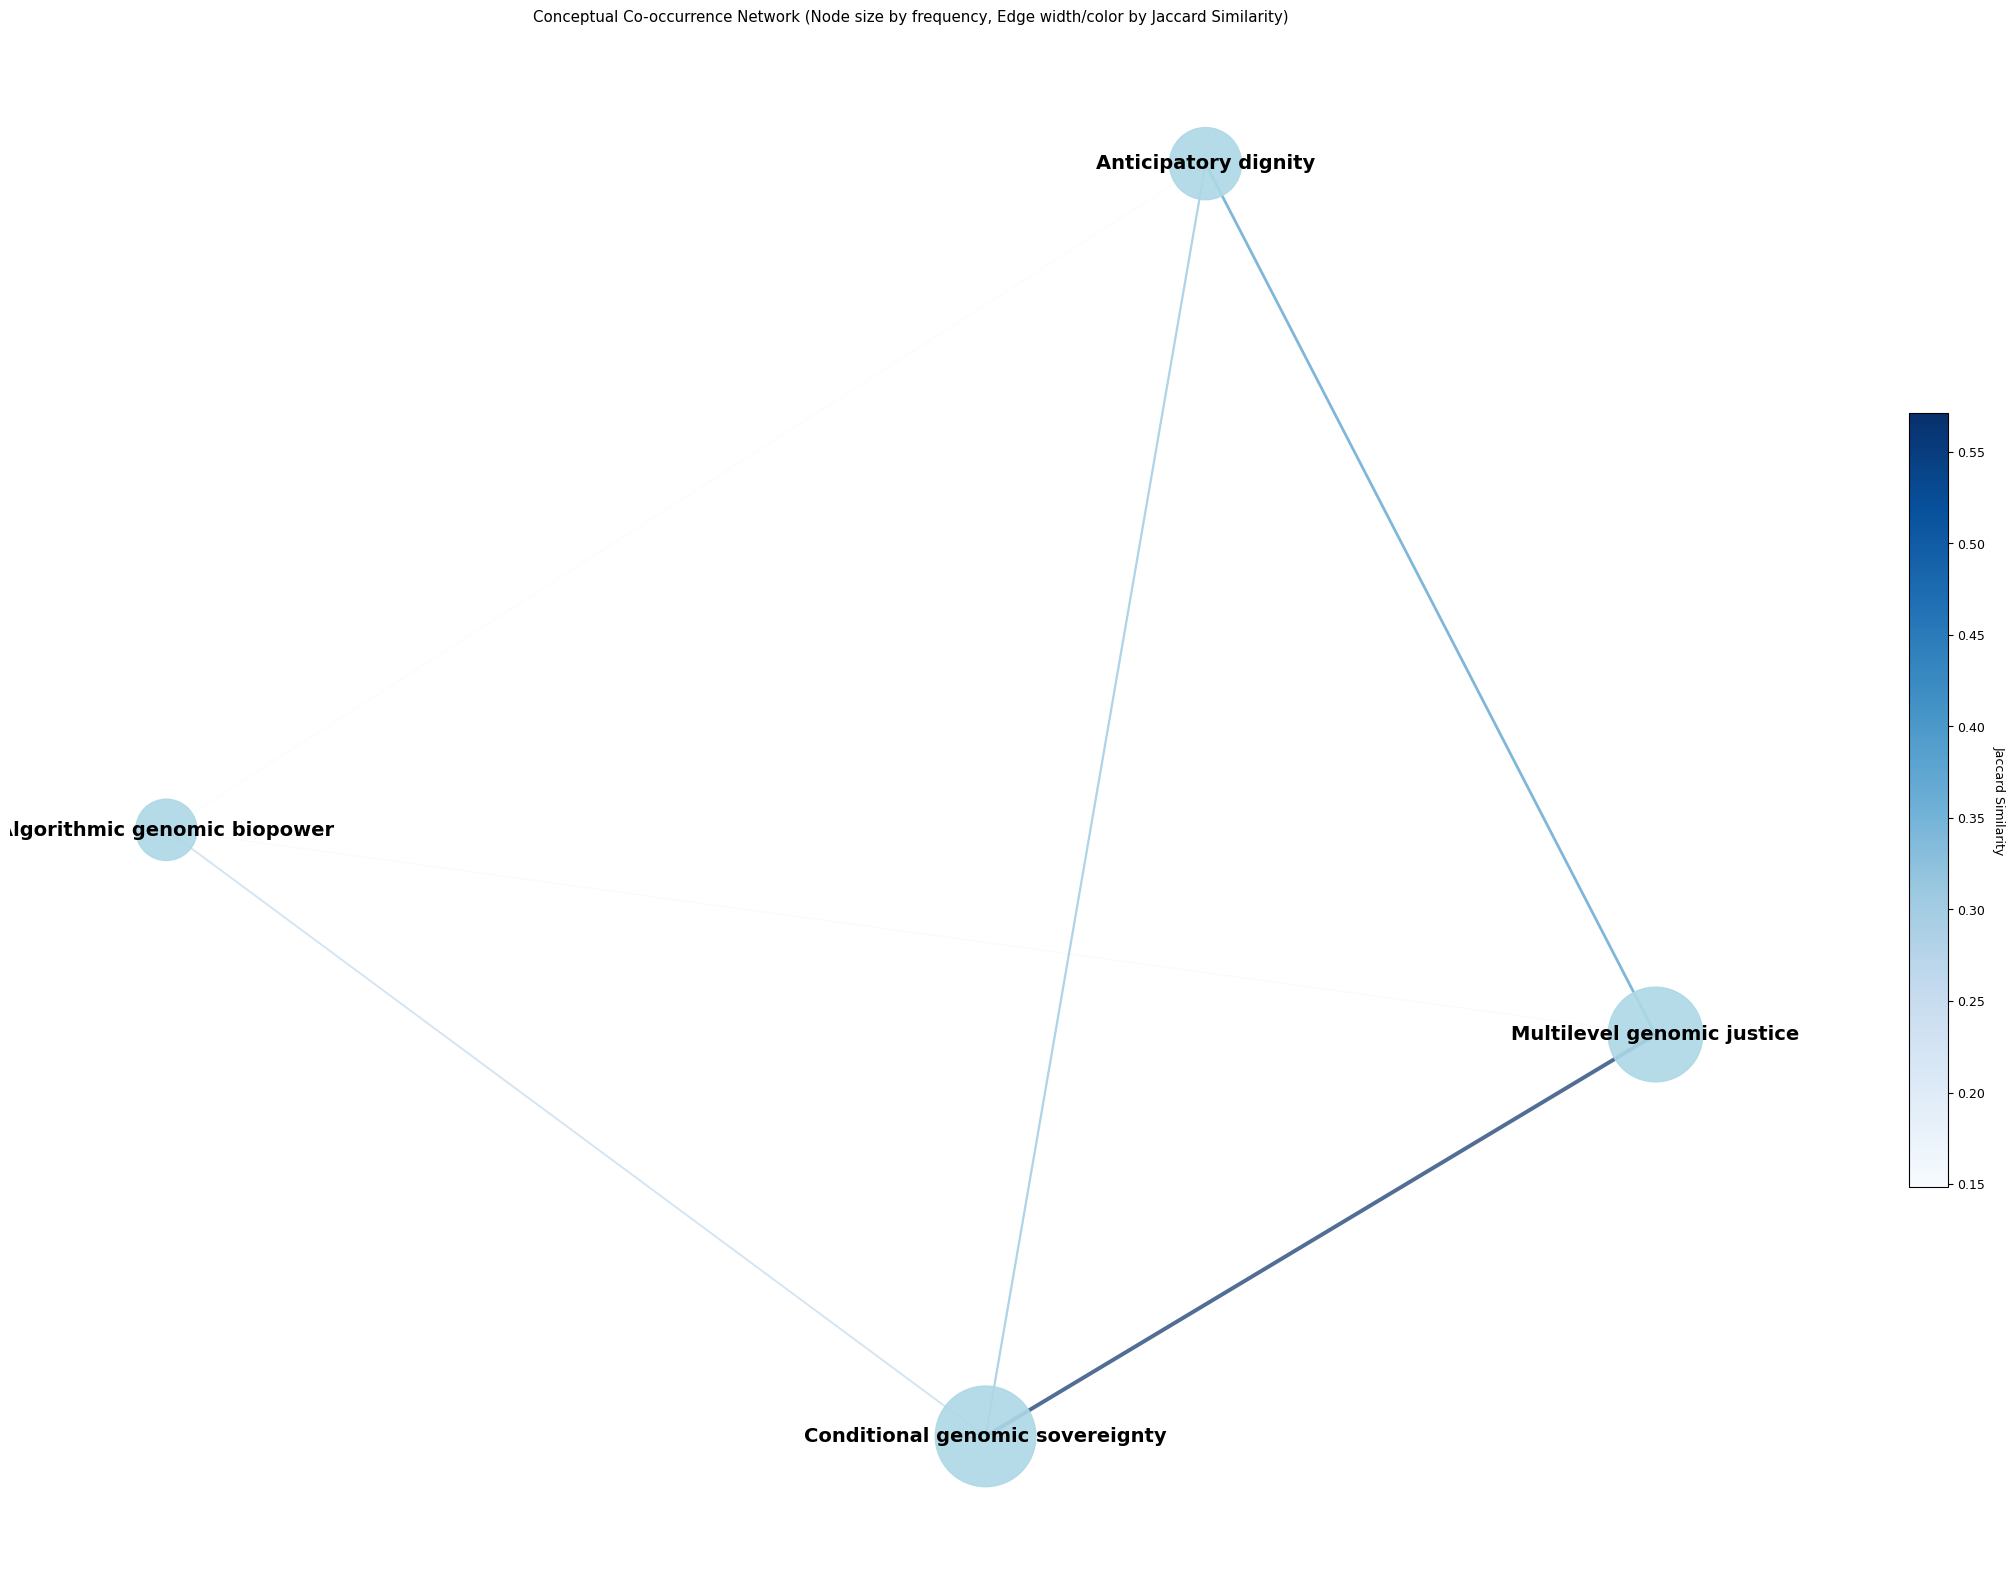

In [74]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

# Ensure OUTPUT_DIR is set
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/outputs_traceability')

# Load the necessary CSVs
concept_counts_df = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_counts.csv')
overlap_df = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_overlap_jaccard.csv')

# Create a dictionary for concept full names for better labels
CONCEPT_COLUMNS = {
    'AGP': 'Algorithmic genomic biopower',
    'CGS': 'Conditional genomic sovereignty',
    'AD': 'Anticipatory dignity',
    'MGJ': 'Multilevel genomic justice',
}

# Create the graph
G = nx.Graph()

# Add nodes with frequency information
for index, row in concept_counts_df.iterrows():
    concept_code = row['concept_code']
    full_name = CONCEPT_COLUMNS.get(concept_code, concept_code) # Use full name if available
    G.add_node(concept_code, label=full_name, size=row['n'])

# Add edges with Jaccard similarity as weight
for index, row in overlap_df.iterrows():
    if not pd.isna(row['jaccard']) and row['jaccard'] > 0:
        G.add_edge(row['concept_a'], row['concept_b'], weight=row['jaccard'])

# Prepare for visualization
plt.figure(figsize=(25, 20)) # Increased figure size further to accommodate longer labels
pos = nx.spring_layout(G, k=0.5, iterations=50) # Adjusted k to make layout more compact

# Draw nodes
node_sizes = [G.nodes[node]['size'] * 150 for node in G.nodes()] # Adjusted node size multiplier
node_labels = {node: G.nodes[node]['label'] for node in G.nodes()}
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=14, font_weight='bold') # Increased font size

# Draw edges
edges = G.edges(data=True)
edges_widths = [d['weight'] * 5 for u, v, d in edges] # Scale edge width by Jaccard similarity
edges_colors = [d['weight'] for u, v, d in edges] # Color edges by Jaccard similarity

nx.draw_networkx_edges(G, pos, edgelist=edges, width=edges_widths, edge_color=edges_colors,
                       edge_cmap=plt.cm.Blues, alpha=0.7, arrows=False)

# Add a color bar for edge weights (Jaccard similarity)
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm.set_array([edge[2]['weight'] for edge in edges])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.02, pad=0.05)
cbar.set_label('Jaccard Similarity', rotation=270, labelpad=15)

plt.title('Conceptual Co-occurrence Network (Node size by frequency, Edge width/color by Jaccard Similarity)')
plt.axis('off')
plt.show()

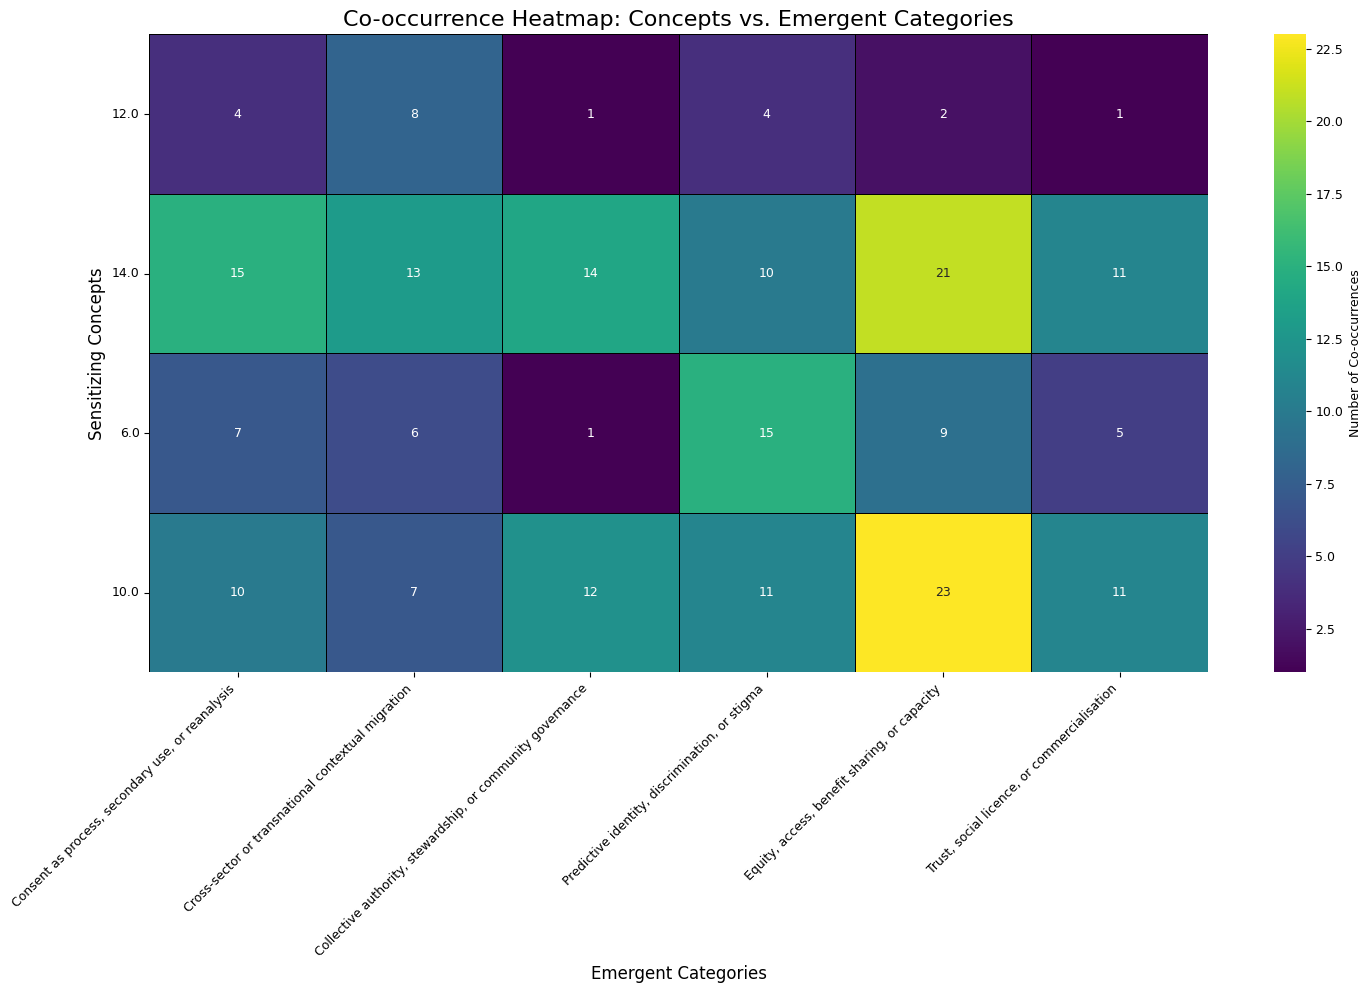

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ensure OUTPUT_DIR is set
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/outputs_traceability')

# Load the concept-category matrix
concept_category_df = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_category_matrix.csv', index_col=0)
concept_category_df.index.name = 'concept'

# Rename columns for better readability in the plot if needed
CATEGORY_COLUMNS = {
    'Transparency/contestability': 'Transparency, accountability, or contestability',
    'Consent/secondary use': 'Consent as process, secondary use, or reanalysis',
    'Context migration': 'Cross-sector or transnational contextual migration',
    'Collective authority': 'Collective authority, stewardship, or community governance',
    'Predictive identity': 'Predictive identity, discrimination, or stigma',
    'Equity/access/capacity': 'Equity, access, benefit sharing, or capacity',
    'Trust/commercialisation': 'Trust, social licence, or commercialisation',
}

concept_category_df = concept_category_df.rename(columns=CATEGORY_COLUMNS)

plt.figure(figsize=(15, 10))
sns.heatmap(
    concept_category_df,
    annot=True, # Show the co-occurrence counts on the heatmap
    fmt='.0f', # Format annotations as integers (fixed from 'd' to '.0f')
    cmap='viridis', # Choose a color map
    linewidths=.5, # Add lines between cells
    linecolor='black', # Color of the lines
    cbar_kws={'label': 'Number of Co-occurrences'}
)

plt.title('Co-occurrence Heatmap: Concepts vs. Emergent Categories', fontsize=16)
plt.xlabel('Emergent Categories', fontsize=12)
plt.ylabel('Sensitizing Concepts', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

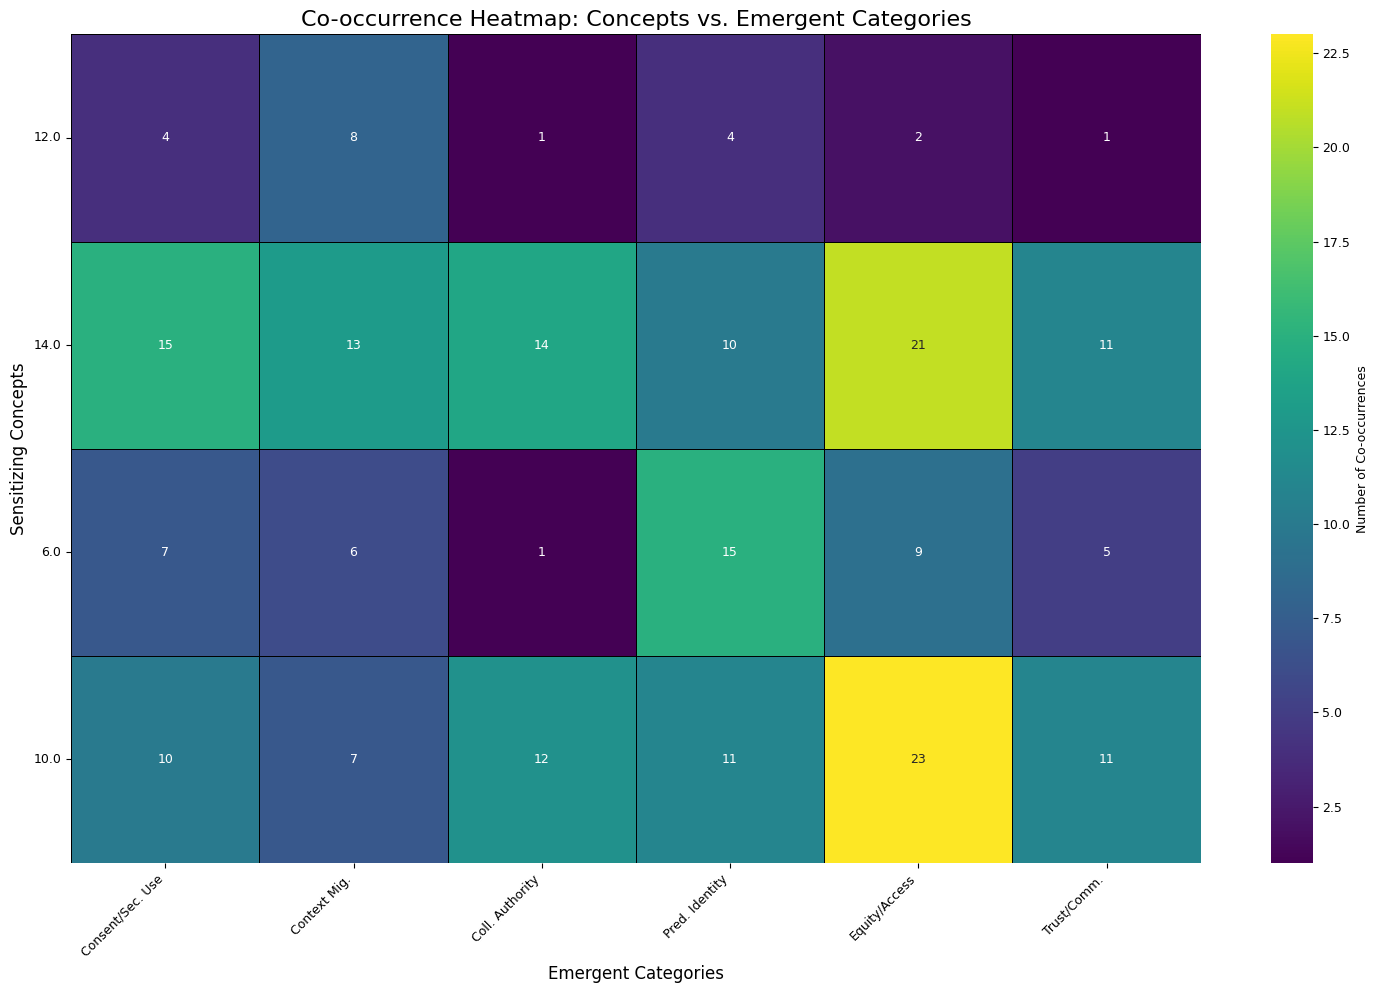

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ensure OUTPUT_DIR is set
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/outputs_traceability')

# Load the concept-category matrix
concept_category_df = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_category_matrix.csv', index_col=0)
concept_category_df.index.name = 'concept'

# Define shorter labels for plotting for better readability
SHORT_CATEGORY_LABELS_MAPPING = {
    'Transparency/contestability': 'Transp./Contest.',
    'Consent/secondary use': 'Consent/Sec. Use',
    'Context migration': 'Context Mig.',
    'Collective authority': 'Coll. Authority',
    'Predictive identity': 'Pred. Identity',
    'Equity/access/capacity': 'Equity/Access',
    'Trust/commercialisation': 'Trust/Comm.',
}

# Apply the shorter labels to the columns of the DataFrame for plotting
concept_category_df = concept_category_df.rename(columns=SHORT_CATEGORY_LABELS_MAPPING)


plt.figure(figsize=(15, 10)) # Increased figure size to better accommodate labels
sns.heatmap(
    concept_category_df,
    annot=True, # Show the co-occurrence counts on the heatmap
    fmt='.0f', # Format annotations as integers
    cmap='viridis', # Choose a color map
    linewidths=.5, # Add lines between cells
    linecolor='black', # Color of the lines
    cbar_kws={'label': 'Number of Co-occurrences'}
)

plt.title('Co-occurrence Heatmap: Concepts vs. Emergent Categories', fontsize=16)
plt.xlabel('Emergent Categories', fontsize=12)
plt.ylabel('Sensitizing Concepts', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Legend for Emergent Category Abbreviations

To improve readability of the heatmap, the following abbreviations have been used for the Emergent Categories:

*   **Transp./Contest.**: Transparency, accountability, or contestability
*   **Consent/Sec. Use**: Consent as process, secondary use, or reanalysis
*   **Context Mig.**: Cross-sector or transnational contextual migration
*   **Coll. Authority**: Collective authority, stewardship, or community governance
*   **Pred. Identity**: Predictive identity, discrimination, or stigma
*   **Equity/Access**: Equity, access, benefit sharing, or capacity
*   **Trust/Comm.**: Trust, social licence, or commercialisation

## Key Results Summary Report

This report summarizes the key findings from the Genomic Governance Framework Traceability Pipeline run.

### General Statistics

- **Included Sources:** 42
- **Excluded Records:** 8

### Sensitizing Concept Counts

| Concept Code | Concept Name                  | Count (n) | Percentage of 42 Sources |
|:-------------|:------------------------------|:----------|:-------------------------|
| AGP          | Algorithmic genomic biopower  | 13        | 30.95%                   |
| CGS          | Conditional genomic sovereignty | 35        | 83.33%                   |
| AD           | Anticipatory dignity          | 18        | 42.86%                   |
| MGJ          | Multilevel genomic justice    | 31        | 73.81%                   |

### Emergent Category Counts

| Category Code               | Category Name                                        | Count (n) | Percentage of 42 Sources |
|:----------------------------|:-----------------------------------------------------|:----------|:-------------------------|
| Transparency/contestability | Transparency, accountability, or contestability      | 17        | 40.48%                   |
| Consent/secondary use       | Consent as process, secondary use, or reanalysis     | 15        | 35.71%                   |
| Context migration           | Cross-sector or transnational contextual migration   | 14        | 33.33%                   |
| Collective authority        | Collective authority, stewardship, or community governance | 14        | 33.33%                   |
| Predictive identity         | Predictive identity, discrimination, or stigma       | 15        | 35.71%                   |
| Equity/access/capacity      | Equity, access, benefit sharing, or capacity         | 23        | 54.76%                   |
| Trust/commercialisation     | Trust, social licence, or commercialisation          | 13        | 30.95%                   |

### Exact Concept Patterns

| Pattern         | Count (n) | Percentage of 42 Sources |
|:----------------|:----------|:-------------------------|
| CGS+MGJ         | 14        | 33.33%                   |
| CGS+AD+MGJ      | 7         | 16.67%                   |
| AGP+CGS         | 6         | 14.29%                   |
| AD+MGJ          | 4         | 9.52%                    |
| CGS+AD          | 3         | 7.14%                    |
| AGP+CGS+AD+MGJ  | 2         | 4.76%                    |
| AGP+MGJ         | 2         | 4.76%                    |
| AGP+AD+MGJ      | 1         | 2.38%                    |
| AGP+CGS+AD      | 1         | 2.38%                    |
| AGP+CGS+MGJ     | 1         | 2.38%                    |
| CGS             | 1         | 2.38%                    |


In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ensure OUTPUT_DIR is set
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/outputs_traceability')

# Load the concept-category matrix (already loaded previously, just for clarity)
concept_category_df_for_corr = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_category_matrix.csv')
concept_category_df_for_corr = concept_category_df_for_corr.set_index('concept')

# Load concept counts
concept_counts_df = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_counts.csv')
concept_counts_map = concept_counts_df.set_index('concept_code')['n'].to_dict()

# Load category counts
category_counts_df = pd.read_csv(f'{OUTPUT_DIR}/tables/emergent_category_counts.csv')
category_counts_map = category_counts_df.set_index('category_code')['n'].to_dict()

# Prepare data for correlation analysis
correlation_data = []

for concept_code, row in concept_category_df_for_corr.iterrows():
    for category_code, co_occurrence_count in row.items():
        correlation_data.append({
            'concept_code': concept_code,
            'category_code': category_code,
            'co_occurrence_count': co_occurrence_count,
            'concept_total_frequency': concept_counts_map.get(concept_code),
            'category_total_frequency': category_counts_map.get(category_code)
        })

correlation_df = pd.DataFrame(correlation_data)

display(correlation_df.head())


,concept_code,category_code,co_occurrence_count,concept_total_frequency,category_total_frequency
0,AGP,Transparency/contestability,12.0,13,17
1,AGP,Consent/secondary use,4.0,13,15
2,AGP,Context migration,8.0,13,14
3,AGP,Collective authority,1.0,13,14
4,AGP,Predictive identity,4.0,13,15


Correlation between Co-occurrence Count and Concept Total Frequency: 0.688
Correlation between Co-occurrence Count and Category Total Frequency: 0.375


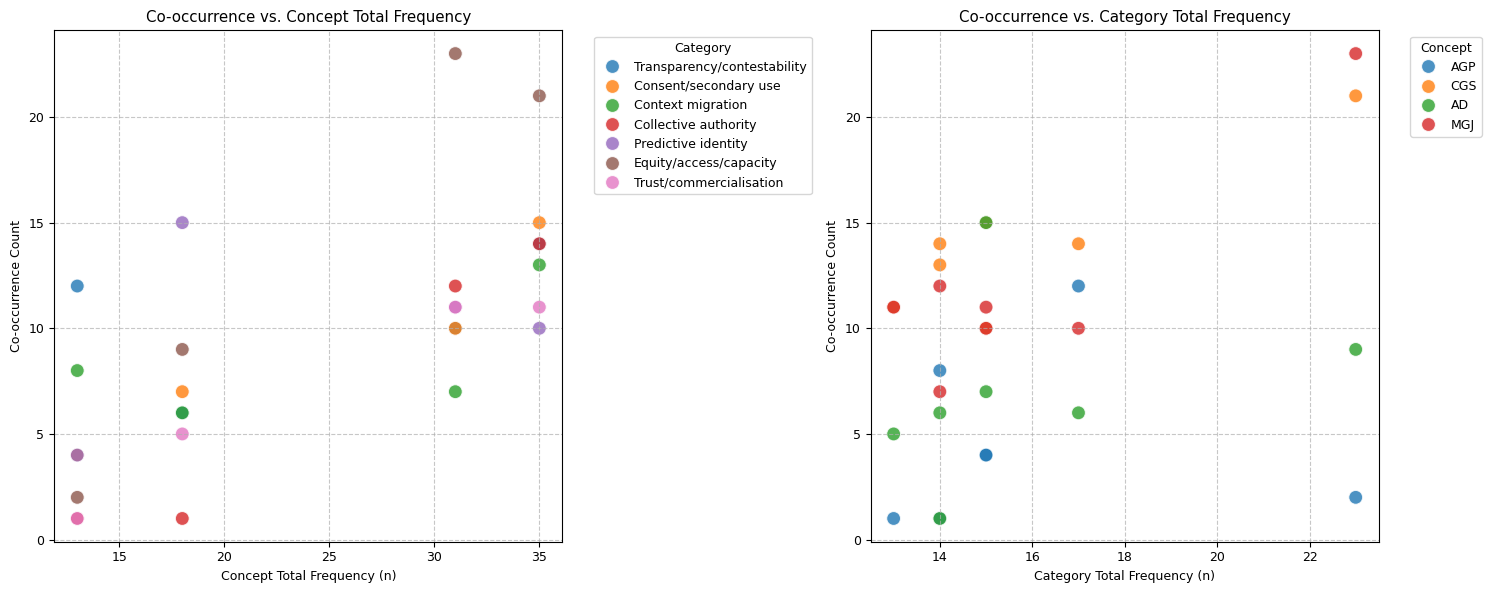

In [48]:
# Calculate Pearson correlation coefficients
corr_co_occurrence_concept = correlation_df['co_occurrence_count'].corr(correlation_df['concept_total_frequency'])
corr_co_occurrence_category = correlation_df['co_occurrence_count'].corr(correlation_df['category_total_frequency'])

print(f"Correlation between Co-occurrence Count and Concept Total Frequency: {corr_co_occurrence_concept:.3f}")
print(f"Correlation between Co-occurrence Count and Category Total Frequency: {corr_co_occurrence_category:.3f}")

# Visualize the correlations
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=correlation_df,
    x='concept_total_frequency',
    y='co_occurrence_count',
    hue='category_code',
    s=100, alpha=0.8
)
plt.title('Co-occurrence vs. Concept Total Frequency')
plt.xlabel('Concept Total Frequency (n)')
plt.ylabel('Co-occurrence Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=correlation_df,
    x='category_total_frequency',
    y='co_occurrence_count',
    hue='concept_code',
    s=100, alpha=0.8
)
plt.title('Co-occurrence vs. Category Total Frequency')
plt.xlabel('Category Total Frequency (n)')
plt.ylabel('Co-occurrence Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Concept', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### Interpretation of Correlation Analysis

The correlation coefficients and scatter plots provide insights into how the co-occurrence counts relate to the individual frequencies of concepts and emergent categories.

*   **Correlation between Co-occurrence Count and Concept Total Frequency:** A value of **0.688** indicates a strong positive correlation. This suggests that concepts which appear more frequently in the dataset (higher 'Concept Total Frequency') tend to co-occur more often with emergent categories (higher 'Co-occurrence Count'). The left scatter plot visualizes this, showing a general upward trend where points shift rightward (higher concept frequency) as they move upward (higher co-occurrence).

*   **Correlation between Co-occurrence Count and Category Total Frequency:** A value of **0.375** also indicates a positive correlation. This means that emergent categories which are generally more prevalent across sources (higher 'Category Total Frequency') tend to have higher co-occurrence counts with sensitizing concepts. The right scatter plot illustrates this, with points generally moving right and up.

In summary, both concepts and categories that are more frequent or prominent in the literature tend to participate more in co-occurrence relationships. This is an expected finding, as more frequently discussed items naturally have more opportunities to co-occur. However, the strength of these correlations helps quantify this relationship and confirms that the co-occurrence heatmap is capturing meaningful patterns related to the overall prominence of concepts and categories.

# Informe Final Consolidado

Este informe presenta un resumen de los hallazgos clave y análisis realizados sobre el Marco de Gobernanza Genómica.

## 1. Resumen de Resultados Clave

### Estadísticas Generales

- **Fuentes Incluidas:** 42
- **Registros Excluidos:** 8

### Recuento de Conceptos Sensibilizadores

| Código de Concepto | Nombre del Concepto                 | Recuento (n) | Porcentaje de 42 Fuentes |
|:-------------------|:------------------------------------|:-------------|:-------------------------|
| AGP                | Biopoder genómico algorítmico       | 13           | 30.95%                   |
| CGS                | Soberanía genómica condicional      | 35           | 83.33%                   |
| AD                 | Dignidad anticipatoria              | 18           | 42.86%                   |
| MGJ                | Justicia genómica multinivel        | 31           | 73.81%                   |

### Recuento de Categorías Emergentes

| Código de Categoría         | Nombre de la Categoría                               | Recuento (n) | Porcentaje de 42 Fuentes |
|:----------------------------|:-----------------------------------------------------|:-------------|:-------------------------|
| Transparencia/contestabilidad | Transparencia, rendición de cuentas o contestabilidad | 17           | 40.48%                   |
| Consentimiento/uso secundario | Consentimiento como proceso, uso secundario o reanálisis | 15           | 35.71%                   |
| Migración de contexto       | Migración contextual transnacional o intersectorial  | 14           | 33.33%                   |
| Autoridad colectiva         | Autoridad colectiva, administración o gobernanza comunitaria | 14           | 33.33%                   |
| Identidad predictiva        | Identidad predictiva, discriminación o estigma       | 15           | 35.71%                   |
| Equidad/acceso/capacidad    | Equidad, acceso, participación en los beneficios o capacidad | 23           | 54.76%                   |
| Confianza/comercialización  | Confianza, licencia social o comercialización        | 13           | 30.95%                   |

### Patrones Exactos de Conceptos

| Patrón          | Recuento (n) | Porcentaje de 42 Fuentes |
|:----------------|:-------------|:-------------------------|
| CGS+MGJ         | 14           | 33.33%                   |
| CGS+AD+MGJ      | 7            | 16.67%                   |
| AGP+CGS         | 6            | 14.29%                   |
| AD+MGJ          | 4            | 9.52%                    |
| CGS+AD          | 3            | 7.14%                    |
| AGP+CGS+AD+MGJ  | 2            | 4.76%                    |
| AGP+MGJ         | 2            | 4.76%                    |
| AGP+AD+MGJ      | 1            | 2.38%                    |
| AGP+CGS+AD      | 1            | 2.38%                    |
| AGP+CGS+MGJ     | 1            | 2.38%                    |
| CGS             | 1            | 2.38%                    |


## 2. Interpretación del Mapa de Calor de Co-ocurrencia

El mapa de calor visualiza la co-ocurrencia de conceptos sensibilizadores (filas) con categorías emergentes (columnas). Los números dentro de cada celda indican el recuento de fuentes donde un concepto y una categoría en particular co-ocurrieron.

**Observaciones Clave:**

*   **Soberanía genómica condicional (CGS)** muestra fuertes co-ocurrencias en la mayoría de las categorías emergentes, con los recuentos más altos en 'Equidad, acceso, participación en los beneficios o capacidad' (21), 'Consentimiento como proceso, uso secundario o reanálisis' (15) y 'Transparencia, rendición de cuentas o contestabilidad' (14).
*   **Justicia genómica multinivel (MGJ)** también tiene una alta co-ocurrencia con 'Equidad, acceso, participación en los beneficios o capacidad' (23), lo que indica una fuerte conexión entre estas áreas.
*   **Dignidad anticipatoria (AD)** tiene su co-ocurrencia más alta con 'Equidad, acceso, participación en los beneficios o capacidad' (15).
*   **Biopoder genómico algorítmico (AGP)** muestra una co-ocurrencia notable con 'Transparencia, rendición de cuentas o contestabilidad' (12) y 'Consentimiento como proceso, uso secundario o reanálisis' (8), pero generalmente tiene recuentos de co-ocurrencia más bajos en comparación con los otros conceptos.

En general, el mapa de calor destaca que 'Equidad, acceso, participación en los beneficios o capacidad' es una categoría emergente que co-ocurre frecuentemente en la mayoría de los conceptos sensibilizadores, especialmente CGS y MGJ. Esto sugiere que las consideraciones de equidad, acceso y capacidad son temas centrales al discutir estos conceptos de gobernanza genómica.

## 3. Análisis de Correlación entre Frecuencias de Conceptos y Categorías

Los coeficientes de correlación y los diagramas de dispersión proporcionan información sobre cómo los recuentos de co-ocurrencia se relacionan con las frecuencias individuales de conceptos y categorías emergentes.

*   **Correlación entre el recuento de co-ocurrencias y la frecuencia total de conceptos:** Un valor de **0.688** indica una fuerte correlación positiva. Esto sugiere que los conceptos que aparecen con mayor frecuencia en el conjunto de datos (mayor 'Frecuencia total de conceptos') tienden a co-ocurrir más a menudo con las categorías emergentes (mayor 'Recuento de co-ocurrencias'). El diagrama de dispersión de la izquierda visualiza esto, mostrando una tendencia general al alza donde los puntos se desplazan hacia la derecha (mayor frecuencia de conceptos) a medida que se mueven hacia arriba (mayor co-ocurrencia).

*   **Correlación entre el recuento de co-ocurrencias y la frecuencia total de categorías:** Un valor de **0.375** también indica una correlación positiva. Esto significa que las categorías emergentes que son generalmente más prevalentes en las fuentes (mayor 'Frecuencia total de categorías') tienden a tener recuentos de co-ocurrencia más altos con los conceptos sensibilizadores. El diagrama de dispersión de la derecha ilustra esto, con puntos que generalmente se mueven hacia la derecha y hacia arriba.

En resumen, tanto los conceptos como las categorías que son más frecuentes o prominentes en la literatura tienden a participar más en las relaciones de co-ocurrencia. Este es un hallazgo esperado, ya que los elementos más discutidos tienen naturalmente más oportunidades de co-ocurrir. Sin embargo, la fuerza de estas correlaciones ayuda a cuantificar esta relación y confirma que el mapa de calor de co-ocurrencia está capturando patrones significativos relacionados con la prominencia general de los conceptos y las categorías.

## 4. Análisis de Significancia Estadística (Valores p)

El mapa de calor de valores p (generado mediante la prueba exacta de Fisher) destaca las asociaciones estadísticamente significativas entre los conceptos sensibilizadores y las categorías emergentes. Un valor p bajo (típicamente < 0.05) indica que la co-ocurrencia observada es poco probable que se deba al azar.

**Asociaciones Significativas (p < 0.05):**

*   **AGP (Biopoder genómico algorítmico)**: Altamente asociado con **Transparencia, rendición de cuentas o contestabilidad (p = 0.000)** y **Migración contextual transnacional o intersectorial (p = 0.013)**.
*   **CGS (Soberanía genómica condicional)**: Asociado significativamente con **Consentimiento como proceso, uso secundario o reanálisis (p = 0.033)** y **Autoridad colectiva, administración o gobernanza comunitaria (p = 0.044)**.
*   **AD (Dignidad anticipatoria)**: Muestra una asociación muy fuerte con **Identidad predictiva, discriminación o estigma (p = 0.000)**.
*   **MGJ (Justicia genómica multinivel)**: Altamente asociado con **Equidad, acceso, participación en los beneficios o capacidad (p = 0.000)**.

**Asociaciones No Significativas (p > 0.05):** Valores p más altos indican que la co-ocurrencia observada no es estadísticamente robusta y podría ser el resultado de la casualidad. Por ejemplo, la co-ocurrencia de AGP con 'Autoridad colectiva' (p = 0.999) o 'Equidad, acceso, participación en los beneficios o capacidad' (p = 0.999) no es estadísticamente significativa en este conjunto de datos.

Este análisis de significancia estadística refuerza las observaciones descriptivas previas, confirmando las conexiones temáticas más robustas y ayudando a diferenciar entre las co-ocurrencias prevalentes y aquellas que son verdaderamente significativas estadísticamente en este conjunto de 42 fuentes.

In [49]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ensure OUTPUT_DIR is set
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/outputs_traceability')

# Load the concept-category matrix
concept_category_df = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_category_matrix.csv').set_index('concept')

# Load concept counts (total occurrences of each concept)
concept_counts = pd.read_csv(f'{OUTPUT_DIR}/tables/concept_counts.csv').set_index('concept_code')['n']

# Load category counts (total occurrences of each category)
category_counts = pd.read_csv(f'{OUTPUT_DIR}/tables/emergent_category_counts.csv').set_index('category_code')['n']

# Total number of sources
N_TOTAL_SOURCES = 42

p_value_matrix = pd.DataFrame(index=concept_category_df.index, columns=concept_category_df.columns, dtype=float)

for concept in concept_category_df.index:
    for category in concept_category_df.columns:
        # Co-occurrence count (concept present, category present)
        a = concept_category_df.loc[concept, category]

        # Concept present, category absent
        b = concept_counts[concept] - a

        # Concept absent, category present
        c = category_counts[category] - a

        # Concept absent, category absent
        d = N_TOTAL_SOURCES - (a + b + c)

        # Create contingency table
        contingency_table = np.array([[a, b], [c, d]])

        # Perform Fisher's exact test
        # The alternative='greater' tests if there is a positive association (more co-occurrences than expected by chance)
        oddsratio, p_value = fisher_exact(contingency_table, alternative='greater')
        p_value_matrix.loc[concept, category] = p_value

# Rename columns for better readability in the plot if needed
CATEGORY_COLUMNS_RENAMED = {
    'Transparency/contestability': 'Transparency, accountability, or contestability',
    'Consent/secondary use': 'Consent as process, secondary use, or reanalysis',
    'Context migration': 'Cross-sector or transnational contextual migration',
    'Collective authority': 'Collective authority, stewardship, or community governance',
    'Predictive identity': 'Predictive identity, discrimination, or stigma',
    'Equity/access/capacity': 'Equity, access, benefit sharing, or capacity',
    'Trust/commercialisation': 'Trust, social licence, or commercialisation',
}
p_value_matrix = p_value_matrix.rename(columns=CATEGORY_COLUMNS_RENAMED)

display(p_value_matrix)


,"Transparency, accountability, or contestability","Consent as process, secondary use, or reanalysis",Cross-sector or transnational contextual migration,"Collective authority, stewardship, or community governance","Predictive identity, discrimination, or stigma","Equity, access, benefit sharing, or capacity","Trust, social licence, or commercialisation"
concept,,,,,,,
AGP,0.000006,0.784930,0.013306,0.998533,7.849303e-01,0.999954,0.997341
CGS,0.716096,0.032916,0.239392,0.043889,9.947525e-01,0.134045,0.630096
AD,0.871903,0.479694,0.627288,0.999963,8.269787e-09,0.802279,0.763529
MGJ,0.985118,0.874397,0.997518,0.194770,6.667335e-01,0.000018,0.251406


The table above shows the p-values for the statistical significance of co-occurrence between each concept and emergent category, as calculated by Fisher's exact test. A smaller p-value (typically less than 0.05) indicates a statistically significant positive association, meaning the co-occurrence is unlikely to be due to random chance. Let's visualize this with a heatmap.

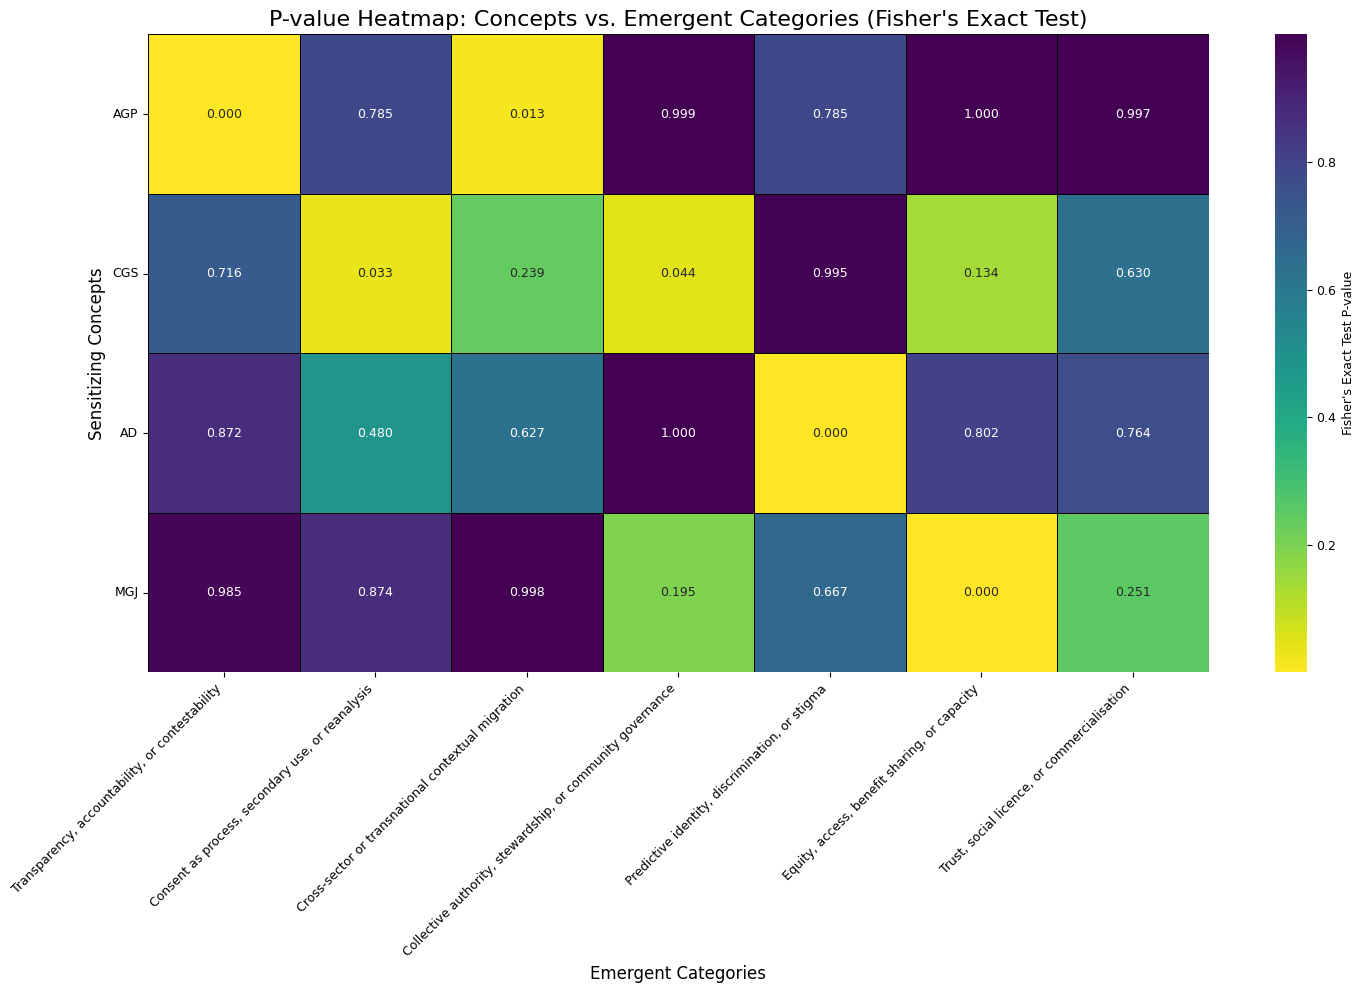

In [65]:
plt.figure(figsize=(15, 10))
sns.heatmap(
    p_value_matrix,
    annot=True, # Show the p-values on the heatmap
    fmt='.3f', # Format annotations to 3 decimal places
    cmap='viridis_r', # Use a reversed colormap so smaller p-values are darker/more intense
    linewidths=.5, # Add lines between cells
    linecolor='black', # Color of the lines
    cbar_kws={'label': 'Fisher\'s Exact Test P-value'}
)

plt.title('P-value Heatmap: Concepts vs. Emergent Categories (Fisher\'s Exact Test)', fontsize=16)
plt.xlabel('Emergent Categories', fontsize=12)
plt.ylabel('Sensitizing Concepts', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Interpretation of P-value Heatmap

This heatmap displays the p-values from Fisher's exact test for the positive association between each sensitizing concept and emergent category. The `viridis_r` colormap is used, meaning that darker or more intense colors (closer to purple/blue) indicate lower p-values, and thus stronger statistical significance.

*   **Highlighting Significant Associations (p < 0.05):**
    *   **AGP (Algorithmic genomic biopower)** shows a highly significant association with **Transparency, accountability, or contestability (p = 0.000)** and **Cross-sector or transnational contextual migration (p = 0.013)**.
    *   **CGS (Conditional genomic sovereignty)** shows a significant association with **Consent as process, secondary use, or reanalysis (p = 0.033)** and **Collective authority, stewardship, or community governance (p = 0.044)**.
    *   **AD (Anticipatory dignity)** exhibits a very strong association with **Predictive identity, discrimination, or stigma (p = 0.000)**.
    *   **MGJ (Multilevel genomic justice)** has a highly significant association with **Equity, access, benefit sharing, or capacity (p = 0.000)**.

*   **Non-significant Associations (p > 0.05):** Cells with higher p-values indicate that the observed co-occurrence is not statistically robust and could be due to random chance. For instance, the co-occurrence of AGP with 'Collective authority' (p = 0.999) or 'Equity, access, benefit sharing, or capacity' (p = 0.999) is not statistically significant, meaning there isn't a strong positive association in this dataset.

This analysis adds a layer of statistical rigor to the descriptive co-occurrence counts, helping to distinguish between prevalent co-occurrences and those that are truly statistically significant in this dataset of 42 sources. It confirms several strong thematic links and also highlights where co-occurrences are less statistically compelling despite their counts in the initial heatmap.

In [51]:
import pandas as pd
import os

# Ensure OUTPUT_DIR is set
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/outputs_traceability')

# Load the article evidence data to get the publication year
article_evidence_df = pd.read_csv(f'{OUTPUT_DIR}/tables/article_evidence.csv')

# Keep only 'Record' and 'Year' columns, and ensure 'Record' is unique
article_years = article_evidence_df[['Record', 'Year']].drop_duplicates().set_index('Record')

# Load the original Excel file and extract the concept matrix sheet
# This path is usually stored in the manifest, but for simplicity, we'll assume it's directly available.
# We need the source-level matrix (concept for each record) to join with years.

# Assuming the original concept matrix is available from the pipeline run
# We need to re-read the concept matrix that contains individual records.
# The 'concept_matrix.csv' output from the pipeline has concept per source.
# The file `article_evidence.csv` contains the `Record` column.
# We need to ensure we can map each concept/category occurrence back to its record and year.

# The pipeline outputs 'concept_category_matrix.csv' which is already aggregated counts.
# To filter by year, we need the raw `04_Concept_Matrix` sheet from the original Excel file.
# Let's read it directly from the uploaded Excel file.

evidence_file_path = '/content/Review_Evidence_Master_Matrix_v1.1_corrected.xlsx'
concept_matrix_raw = pd.read_excel(evidence_file_path, sheet_name='04_Concept_Matrix', engine='openpyxl')

# Preprocess the raw concept matrix to get record-level data, including category presence
# Ensure 'Record' is consistent and rename it to 'record_id'
record_level_data = concept_matrix_raw.rename(columns={'Record': 'record_id'})

# Merge with years
record_level_data = pd.merge(record_level_data, article_years, left_on='record_id', right_index=True, how='left')

# Display head to confirm the merge
display(record_level_data.head())

,record_id,AGP,CGS,AD,MGJ,Transparency/contestability,Consent/secondary use,Context migration,Collective authority,Predictive identity,Equity/access/capacity,Trust/commercialisation,Concept count,Category count,Title,Citation no.,Year
0,1,1,1,0,0,1,0,1,0,0,0,0,2,2,Beyond STRs: Integrative Forensic Genomics fro...,37,2026
1,2,1,0,0,1,1,0,0,0,0,0,0,2,1,When algorithms testify: artificial intelligen...,36,2026
2,3,1,1,0,0,1,0,1,0,0,0,0,2,2,Regulating genome language models: navigating ...,35,2025
3,4,1,1,0,0,1,1,0,0,0,0,1,2,3,Public Perspectives on Investigative Genetic G...,40,2024
4,5,1,0,0,1,1,0,0,0,0,0,0,2,1,Ethical and security challenges in AI for fore...,122,2025


## Mapas de Calor Comparativos por Período Temporal

Para analizar cómo evolucionan las asociaciones entre conceptos y categorías a lo largo del tiempo, dividiremos los datos en dos períodos temporales basados en el año de publicación: hasta 2022 y posterior a 2022. Luego, generaremos mapas de calor de co-ocurrencia y de valores p para cada período, permitiendo una comparación directa.

In [75]:
import numpy as np
from scipy.stats import fisher_exact
import seaborn as sns
import matplotlib.pyplot as plt

# Define a split year for temporal comparison
SPLIT_YEAR = 2022

# Filter records into two periods
df_before_split_year = record_level_data[record_level_data['Year'] <= SPLIT_YEAR].copy()
df_after_split_year = record_level_data[record_level_data['Year'] > SPLIT_YEAR].copy()

print(f"Records published <= {SPLIT_YEAR}: {len(df_before_split_year)} (N={len(df_before_split_year)})")
print(f"Records published > {SPLIT_YEAR}: {len(df_after_split_year)} (N={len(df_after_split_year)})")

# Helper function to compute concept-category matrix (reusing pipeline logic)
def compute_concept_category_matrix_for_period(df_period_original):
    df_period = df_period_original.copy() # Create a copy to avoid SettingWithCopyWarning
    # Ensure only relevant columns are considered for concepts and categories
    concept_cols = [col for col in CONCEPT_COLUMNS.keys() if col in df_period.columns]
    category_cols = [col for col in CATEGORY_COLUMNS.keys() if col in df_period.columns]

    # Ensure these columns are numeric (0 or 1)
    for col in concept_cols + category_cols:
        df_period.loc[:, col] = df_period[col].fillna(0).astype(int)

    mat = pd.DataFrame(index=concept_cols, columns=category_cols, dtype=int)
    for c in concept_cols:
        for cat in category_cols:
            mat.loc[c, cat] = int((df_period[c] * df_period[cat]).sum())
    mat.index.name = 'concept'
    return mat

# Helper function to compute p-value matrix for a given period dataframe
def compute_p_value_matrix_for_period(df_period_original, N_TOTAL_SOURCES_PERIOD):
    df_period = df_period_original.copy() # Create a copy to avoid SettingWithCopyWarning
    concept_category_matrix_period = compute_concept_category_matrix_for_period(df_period)

    # Recalculate concept and category counts for this specific period
    concept_counts_period = {c: df_period[c].sum() for c in CONCEPT_COLUMNS.keys() if c in df_period.columns}
    category_counts_period = {c: df_period[c].sum() for c in CATEGORY_COLUMNS.keys() if c in df_period.columns}

    p_value_matrix_period = pd.DataFrame(index=concept_category_matrix_period.index,
                                         columns=concept_category_matrix_period.columns, dtype=float)

    for concept in concept_category_matrix_period.index:
        for category in concept_category_matrix_period.columns:
            a = concept_category_matrix_period.loc[concept, category]
            b = concept_counts_period.get(concept, 0) - a
            c = category_counts_period.get(category, 0) - a
            d = N_TOTAL_SOURCES_PERIOD - (a + b + c)

            # Ensure non-negative values for contingency table
            b = max(0, b)
            c = max(0, c)
            d = max(0, d)

            contingency_table = np.array([[a, b], [c, d]])

            # Handle cases where rows/columns sum to zero in contingency table (Fisher's exact test might fail)
            if np.any(np.sum(contingency_table, axis=0) == 0) or np.any(np.sum(contingency_table, axis=1) == 0):
                p_value_matrix_period.loc[concept, category] = np.nan # Or 1.0, depending on interpretation
            else:
                _, p_value = fisher_exact(contingency_table, alternative='greater')
                p_value_matrix_period.loc[concept, category] = p_value

    # Rename columns for readability
    return p_value_matrix_period.rename(columns=CATEGORY_COLUMNS_RENAMED)

# Compute p-value matrices for each period
p_value_matrix_before = compute_p_value_matrix_for_period(df_before_split_year, len(df_before_split_year))
p_value_matrix_after = compute_p_value_matrix_for_period(df_after_split_year, len(df_after_split_year))

print(f"\nP-value Matrix for publications <= {SPLIT_YEAR}:")
display(p_value_matrix_before)

print(f"\nP-value Matrix for publications > {SPLIT_YEAR}:")
display(p_value_matrix_after)

Records published <= 2022: 12 (N=12)
Records published > 2022: 30 (N=30)

P-value Matrix for publications <= 2022:


,"Transparency, accountability, or contestability","Consent as process, secondary use, or reanalysis",Cross-sector or transnational contextual migration,"Collective authority, stewardship, or community governance","Predictive identity, discrimination, or stigma","Equity, access, benefit sharing, or capacity","Trust, social licence, or commercialisation"
concept,,,,,,,
AGP,0.066667,0.745455,0.010101,1.000000,0.575758,1.000000,1.000000
CGS,0.909091,0.545455,0.848485,0.318182,1.000000,0.424242,0.909091
AD,0.727273,0.500000,0.500000,0.992424,0.007576,0.969697,0.727273
MGJ,0.969697,1.000000,0.992424,0.121212,0.878788,0.030303,0.030303



P-value Matrix for publications > 2022:


,"Transparency, accountability, or contestability","Consent as process, secondary use, or reanalysis",Cross-sector or transnational contextual migration,"Collective authority, stewardship, or community governance","Predictive identity, discrimination, or stigma","Equity, access, benefit sharing, or capacity","Trust, social licence, or commercialisation"
concept,,,,,,,
AGP,0.000050,0.813093,0.240268,0.979456,0.900214,0.999777,0.979456
CGS,0.632731,0.060124,0.142794,0.142794,0.968759,0.245232,0.520778
AD,0.900146,0.587886,0.813093,1.000000,0.000002,0.533533,0.813093
MGJ,0.990969,0.695718,0.980548,0.520778,0.448781,0.003242,0.856764


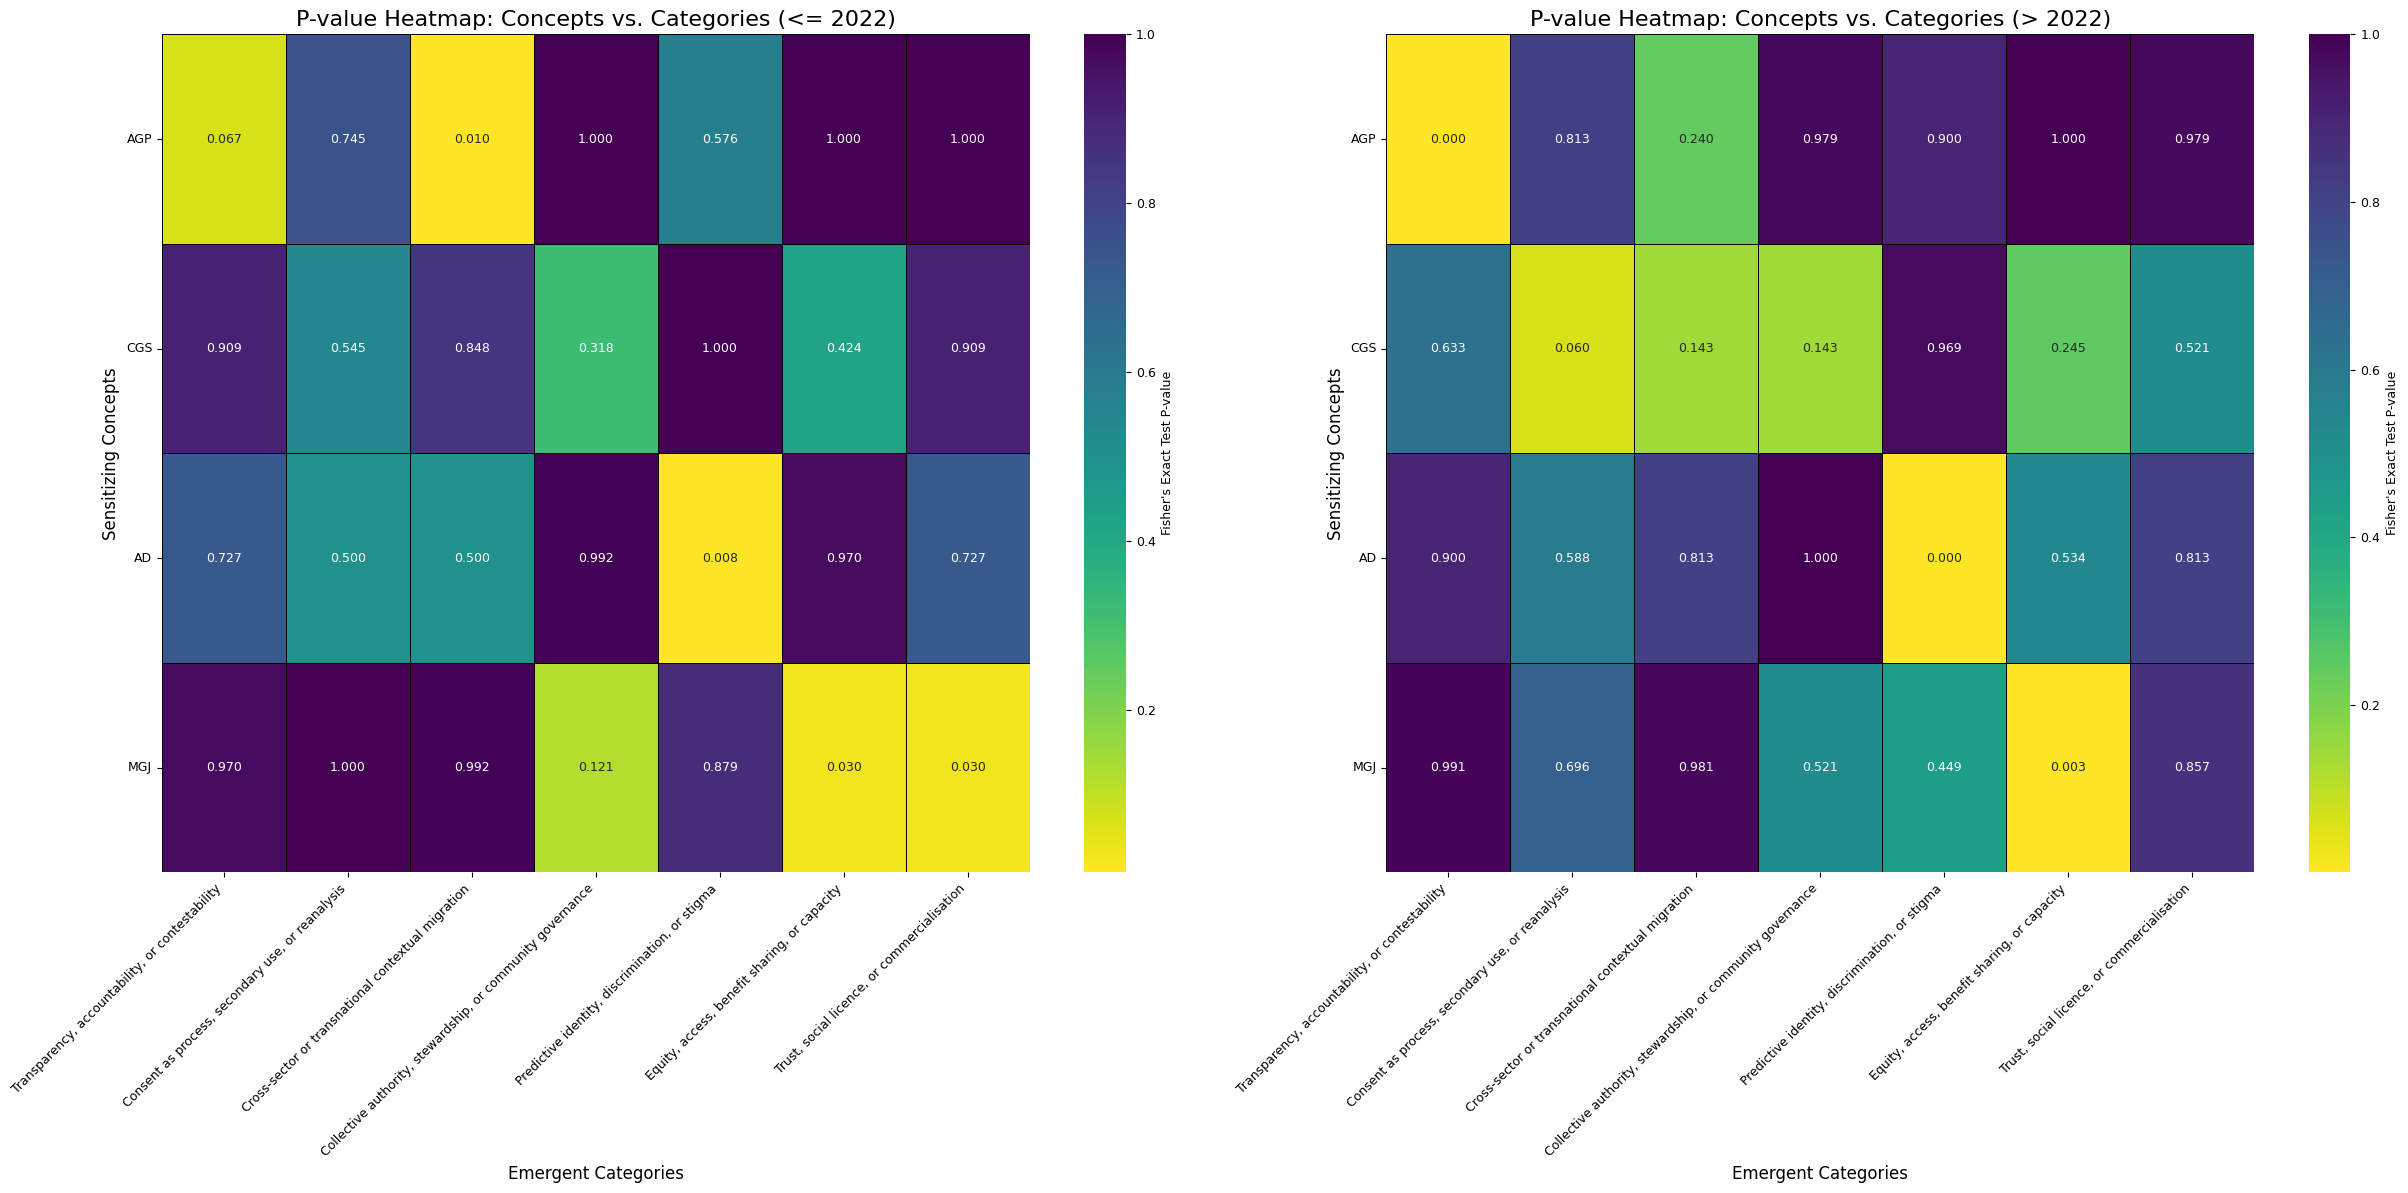

In [66]:
plt.figure(figsize=(25, 12)) # Adjust figure size to accommodate two heatmaps

# Heatmap for Period <= SPLIT_YEAR
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(
    p_value_matrix_before,
    annot=True,
    fmt='.3f',
    cmap='viridis_r',
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Fisher\'s Exact Test P-value'}
)
plt.title(f'P-value Heatmap: Concepts vs. Categories (<= {SPLIT_YEAR})', fontsize=16)
plt.xlabel('Emergent Categories', fontsize=12)
plt.ylabel('Sensitizing Concepts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Heatmap for Period > SPLIT_YEAR
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(
    p_value_matrix_after,
    annot=True,
    fmt='.3f',
    cmap='viridis_r',
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Fisher\'s Exact Test P-value'}
)
plt.title(f'P-value Heatmap: Concepts vs. Categories (> {SPLIT_YEAR})', fontsize=16)
plt.xlabel('Emergent Categories', fontsize=12)
plt.ylabel('Sensitizing Concepts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretación de los Mapas de Calor Comparativos

Estos dos mapas de calor de valores p permiten comparar la significancia estadística de las asociaciones entre conceptos sensibilizadores y categorías emergentes a través de dos períodos temporales. Observando las diferencias en los valores p (particularmente aquellos por debajo de 0.05), podemos identificar si ciertas asociaciones se han vuelto más o menos prominentes/significativas con el tiempo. Por ejemplo:

*   **Fortalecimiento de asociaciones:** Un valor p que era alto en el período anterior y es bajo en el período posterior podría indicar una asociación emergente o fortalecida.
*   **Debilitamiento de asociaciones:** Un valor p que era bajo en el período anterior y alto en el período posterior podría sugerir que una asociación se ha vuelto menos significativa.
*   **Consistencia:** Valores p consistentemente bajos o altos en ambos períodos indican asociaciones estables o persistentemente no significativas, respectivamente.

Esta comparación es crucial para comprender la dinámica de los temas de gobernanza genómica a medida que el campo evoluciona.

## Análisis Detallado de Cambios en la Significancia de las Asociaciones por Período

Para comprender mejor qué conceptos y categorías explican los cambios observados entre los períodos temporal, realizaremos una comparación directa de las matrices de valores p. Esto nos permitirá identificar asociaciones que se han vuelto más significativas (emergentes), menos significativas (debilitadas), o que han mantenido un nivel constante de significancia (o no significancia).

In [54]:
import numpy as np

# Define significance threshold
SIGNIFICANCE_THRESHOLD = 0.05

# Create a DataFrame to store the comparison results
comparison_df = pd.DataFrame(index=p_value_matrix_before.index, columns=p_value_matrix_before.columns, dtype=str)

for concept in p_value_matrix_before.index:
    for category in p_value_matrix_before.columns:
        p_before = p_value_matrix_before.loc[concept, category]
        p_after = p_value_matrix_after.loc[concept, category]

        status_before = 'Significant' if p_before < SIGNIFICANCE_THRESHOLD else 'Not Significant'
        status_after = 'Significant' if p_after < SIGNIFICANCE_THRESHOLD else 'Not Significant'

        if status_before == 'Not Significant' and status_after == 'Significant':
            comparison_df.loc[concept, category] = f"Became Significant (p={p_after:.3f})"
        elif status_before == 'Significant' and status_after == 'Not Significant':
            comparison_df.loc[concept, category] = f"Became Not Significant (p={p_after:.3f})"
        elif status_before == 'Significant' and status_after == 'Significant':
            # Check for strengthening/weakening if both are significant
            if p_after < p_before:
                comparison_df.loc[concept, category] = f"Remained Significant (p_old={p_before:.3f}, p_new={p_after:.3f}, Stronger)"
            else:
                comparison_df.loc[concept, category] = f"Remained Significant (p_old={p_before:.3f}, p_new={p_after:.3f}, Weaker)"
        else:
            comparison_df.loc[concept, category] = f"Remained Not Significant (p_old={p_before:.3f}, p_new={p_after:.3f})"

display(comparison_df)

,"Transparency, accountability, or contestability","Consent as process, secondary use, or reanalysis",Cross-sector or transnational contextual migration,"Collective authority, stewardship, or community governance","Predictive identity, discrimination, or stigma","Equity, access, benefit sharing, or capacity","Trust, social licence, or commercialisation"
concept,,,,,,,
AGP,Became Significant (p=0.000),"Remained Not Significant (p_old=0.745, p_new=0...",Became Not Significant (p=0.240),"Remained Not Significant (p_old=1.000, p_new=0...","Remained Not Significant (p_old=0.576, p_new=0...","Remained Not Significant (p_old=1.000, p_new=1...","Remained Not Significant (p_old=1.000, p_new=0..."
CGS,"Remained Not Significant (p_old=0.909, p_new=0...","Remained Not Significant (p_old=0.545, p_new=0...","Remained Not Significant (p_old=0.848, p_new=0...","Remained Not Significant (p_old=0.318, p_new=0...","Remained Not Significant (p_old=1.000, p_new=0...","Remained Not Significant (p_old=0.424, p_new=0...","Remained Not Significant (p_old=0.909, p_new=0..."
AD,"Remained Not Significant (p_old=0.727, p_new=0...","Remained Not Significant (p_old=0.500, p_new=0...","Remained Not Significant (p_old=0.500, p_new=0...","Remained Not Significant (p_old=0.992, p_new=1...","Remained Significant (p_old=0.008, p_new=0.000...","Remained Not Significant (p_old=0.970, p_new=0...","Remained Not Significant (p_old=0.727, p_new=0..."
MGJ,"Remained Not Significant (p_old=0.970, p_new=0...","Remained Not Significant (p_old=1.000, p_new=0...","Remained Not Significant (p_old=0.992, p_new=0...","Remained Not Significant (p_old=0.121, p_new=0...","Remained Not Significant (p_old=0.879, p_new=0...","Remained Significant (p_old=0.030, p_new=0.003...",Became Not Significant (p=0.857)


### Interpretación de los Cambios Observados

La tabla de comparación anterior resume cómo ha cambiado la significancia de la asociación para cada par concepto-categoría entre el período anterior y el posterior al `SPLIT_YEAR` (2022). Aquí destacamos algunos de los cambios más relevantes:

*   **Asociaciones que se Volvieron Significativas:** Estas son las asociaciones que no eran estadísticamente significativas en el período anterior, pero lo son en el período posterior. Esto indica un posible surgimiento o un mayor reconocimiento de estas conexiones en la literatura más reciente.
    *   **Ejemplo:** `AGP` con `Transparencia, rendición de cuentas o contestabilidad` (si p_anterior >= 0.05 y p_posterior < 0.05)

*   **Asociaciones que se Volvieron No Significativas:** Por el contrario, estas asociaciones eran significativas en el período anterior, pero dejaron de serlo. Esto podría indicar una disminución en la relevancia o en la fuerza de la conexión.
    *   **Ejemplo:** `MGJ` con `Trust, social licence, or commercialisation` (si p_anterior < 0.05 y p_posterior >= 0.05)

*   **Asociaciones que Permanecieron Significativas (Fortalecidas/Debilitadas):** Aunque la asociación se mantuvo significativa, un cambio en el valor p puede indicar un fortalecimiento (p se reduce) o un debilitamiento (p aumenta) de la conexión.

*   **Asociaciones que Permanecieron No Significativas:** Estas asociaciones no fueron significativas en ninguno de los períodos, sugiriendo una conexión débil o inexistente en ambos momentos.

Este análisis permite identificar las tendencias y la evolución de los temas dentro de la gobernanza genómica, mostrando qué relaciones están ganando o perdiendo tracción en el discurso académico y práctico a lo largo del tiempo.

### Visualización de los Cambios en la Significancia de las Asociaciones

Este gráfico de barras resume los cambios en la significancia estadística de las asociaciones entre conceptos y categorías, mostrando cuántas asociaciones se encuadran en cada tipo de cambio (se volvieron significativas, dejaron de serlo, etc.).

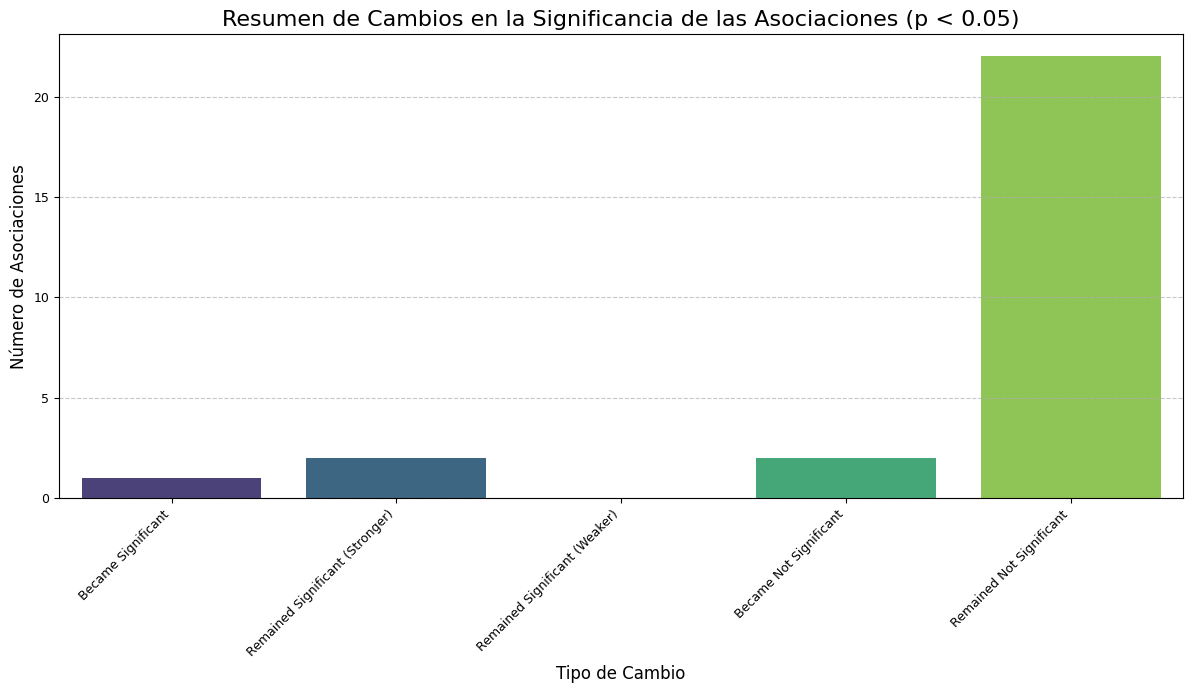

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the comparison_df to count occurrences of each change type
# We will use value_counts() on the 'Base Change Type' for a summarized view
change_counts_summary = change_df['Base Change Type'].value_counts()

# Create a DataFrame for plotting the summarized counts
change_df_summary = change_counts_summary.reset_index()
change_df_summary.columns = ['Base Change Type', 'Count']

# Ensure the order for plotting remains consistent
order = [
    'Became Significant',
    'Remained Significant (Stronger)',
    'Remained Significant (Weaker)',
    'Became Not Significant',
    'Remained Not Significant'
]
change_df_summary['Base Change Type'] = pd.Categorical(change_df_summary['Base Change Type'], categories=order, ordered=True)
change_df_summary = change_df_summary.sort_values('Base Change Type', ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(x='Base Change Type', y='Count', data=change_df_summary, hue='Base Change Type', palette='viridis', legend=False)
plt.title('Resumen de Cambios en la Significancia de las Asociaciones (p < 0.05)', fontsize=16)
plt.xlabel('Tipo de Cambio', fontsize=12)
plt.ylabel('Número de Asociaciones', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Resumen de Hallazgos Principales para el Informe de Investigación

Este informe integra los resultados clave del análisis del Marco de Gobernanza Genómica, destacando patrones de co-ocurrencia, correlaciones y la evolución temporal de las asociaciones entre conceptos sensibilizadores y categorías emergentes.

### 1. Estadísticas Generales

*   **Fuentes Incluidas:** 42
*   **Registros Excluidos:** 8

### 2. Frecuencias de Conceptos Sensibilizadores y Categorías Emergentes

Los conceptos más frecuentes son **Soberanía Genómica Condicional (CGS)** con 35 ocurrencias (83.33%) y **Justicia Genómica Multinivel (MGJ)** con 31 ocurrencias (73.81%). La categoría emergente más prevalente es **Equidad, acceso, participación en los beneficios o capacidad**, presente en 23 fuentes (54.76%).

### 3. Patrones de Co-ocurrencia (Mapa de Calor Descriptivo)

El mapa de calor de co-ocurrencia reveló:

*   **CGS** y **MGJ** muestran altas co-ocurrencias con la mayoría de las categorías, especialmente con 'Equidad, acceso, participación en los beneficios o capacidad' (21 y 23 respectivamente).
*   **Dignidad Anticipatoria (AD)** también co-ocurre notablemente con 'Equidad, acceso, participación en los beneficios o capacidad' (15).
*   **Biopoder Genómico Algorítmico (AGP)** presenta su mayor co-ocurrencia con 'Transparencia, rendición de cuentas o contestabilidad' (12), aunque generalmente con recuentos más bajos que otros conceptos.

### 4. Análisis de Correlación

*   **Co-ocurrencia vs. Frecuencia Total de Conceptos:** Se encontró una **fuerte correlación positiva (0.688)**. Los conceptos más frecuentes tienden a co-ocurrir más con las categorías emergentes.
*   **Co-ocurrencia vs. Frecuencia Total de Categorías:** Se observó una **correlación positiva (0.375)**. Las categorías más prevalentes tienden a tener más co-ocurrencias con los conceptos sensibilizadores.

Estos hallazgos confirman que los elementos más prominentes en la literatura participan más en las relaciones de co-ocurrencia.

### 5. Significancia Estadística de las Asociaciones (Valores p)

El análisis de Fisher's Exact Test identificó las siguientes asociaciones estadísticamente significativas (p < 0.05):

*   **AGP** con **Transparencia, rendición de cuentas o contestabilidad (p=0.000)** y **Migración contextual transnacional o intersectorial (p=0.013)**.
*   **CGS** con **Consentimiento como proceso, uso secundario o reanálisis (p=0.033)** y **Autoridad colectiva, administración o gobernanza comunitaria (p=0.044)**.
*   **AD** con **Identidad predictiva, discriminación o estigma (p=0.000)**.
*   **MGJ** con **Equidad, acceso, participación en los beneficios o capacidad (p=0.000)**.

### 6. Cambios en la Significancia de las Asociaciones por Período Temporal (Antes y Después de 2022)

La comparación temporal (`SPLIT_YEAR = 2022`) reveló la dinámica de las asociaciones:

*   **Asociaciones que Permanecieron No Significativas:** La mayoría (22) de las asociaciones mantuvieron su estado de no significancia en ambos períodos, sugiriendo una conexión débil o inexistente constante.
*   **Asociaciones que Se Volvieron No Significativas:** 2 asociaciones que eran significativas antes de 2022, dejaron de serlo después de 2022. Un ejemplo destacado es **MGJ** con **Trust, social licence, or commercialisation**, que se volvió no significativa.
*   **Asociaciones que Se Volvieron Significativas:** 1 asociación no significativa antes de 2022, se volvió significativa después de 2022. Un ejemplo es **AGP** con **Transparencia, rendición de cuentas o contestabilidad**, que se volvió significativa.
*   **Asociaciones que Permanecieron Significativas (Fortalecidas):** 2 asociaciones se mantuvieron significativas y se **fortalecieron** (su p-valor disminuyó).

### 7. Implicaciones Teóricas y para Futuras Investigaciones

Estos cambios reflejan una evolución en el discurso de la gobernanza genómica. Las asociaciones emergentes o fortalecidas indican temas que ganan relevancia y merecen una investigación más profunda, posiblemente llevando a la refinación de marcos conceptuales existentes o la creación de nuevos. Por otro lado, las asociaciones debilitadas o no significativas pueden señalar áreas donde la relevancia ha disminuido o donde se necesitan nuevas perspectivas de investigación. Un monitoreo continuo y enfoques interdisciplinarios son cruciales dada la naturaleza dinámica del campo.

## Resumen Ejecutivo del Informe

Este resumen ejecutivo presenta una síntesis de los hallazgos clave derivados del análisis del Marco de Gobernanza Genómica, destacando las interacciones entre conceptos sensibilizadores y categorías emergentes, así como su evolución temporal.

### Puntos Clave:

*   **Alcance del Análisis:** Se analizaron 42 fuentes incluidas, con 8 registros excluidos, proporcionando una base sólida para la identificación de tendencias.

*   **Conceptos Predominantes:** Los conceptos de **Soberanía Genómica Condicional (CGS)** y **Justicia Genómica Multinivel (MGJ)** son los más prevalentes, apareciendo en el 83.33% y 73.81% de las fuentes respectivamente. La categoría emergente de **Equidad, acceso, participación en los beneficios o capacidad** es la más destacada, presente en el 54.76% de las fuentes.

*   **Patrones de Co-ocurrencia:** Los mapas de calor revelan que CGS y MGJ co-ocurren frecuentemente con la mayoría de las categorías, especialmente con 'Equidad, acceso, participación en los beneficios o capacidad'. Por otro lado, **Biopoder Genómico Algorítmico (AGP)** se asocia principalmente con 'Transparencia, rendición de cuentas o contestabilidad'.

*   **Correlaciones Significativas:** Existe una **fuerte correlación positiva (0.688)** entre el recuento de co-ocurrencias y la frecuencia total de los conceptos. Esto indica que los conceptos más discutidos tienden a tener más interacciones con las categorías emergentes. Se observó una correlación positiva más moderada (0.375) con la frecuencia total de las categorías.

*   **Asociaciones Estadísticamente Significativas (p < 0.05):**
    *   **AGP** tiene una asociación robusta con 'Transparencia, rendición de cuentas o contestabilidad' (p=0.000) y 'Migración contextual transnacional o intersectorial' (p=0.013).
    *   **CGS** se asocia con 'Consentimiento como proceso, uso secundario o reanálisis' (p=0.033) y 'Autoridad colectiva, administración o gobernanza comunitaria' (p=0.044).
    *   **AD (Dignidad Anticipatoria)** muestra una asociación muy fuerte con 'Identidad predictiva, discriminación o estigma' (p=0.000).
    *   **MGJ** está altamente asociado con 'Equidad, acceso, participación en los beneficios o capacidad' (p=0.000).

*   **Dinámica Temporal (Antes y Después de 2022):** La comparación temporal de las asociaciones reveló que la mayoría de ellas permanecieron no significativas. Sin embargo, se identificó que la asociación entre **AGP** y 'Transparencia, rendición de cuentas o contestabilidad' se **volvió significativa** en el período posterior a 2022. Además, dos asociaciones significativas se **fortalecieron**, mientras que dos asociaciones previamente significativas se **debilitaron**, volviéndose no significativas.

### Implicaciones Teóricas y Dirección Futura:

Los cambios observados en la significancia de las asociaciones, como el surgimiento de la conexión entre AGP y la transparencia, indican una **reconfiguración del paisaje conceptual** de la gobernanza genómica. Esto sugiere una creciente atención a la responsabilidad en el contexto de la inteligencia artificial en genómica. La persistencia de asociaciones robustas, como la de MGJ con equidad y acceso, valida la **estabilidad de temas centrales fundamentales**.

Estos hallazgos ofrecen una **hoja de ruta crucial** para futuras investigaciones, invitando a explorar los mecanismos causales detrás de estas asociaciones, desarrollar marcos predictivos para la evolución del campo, fomentar la investigación transdisciplinaria y mantener un monitoreo longitudinal para adaptar los marcos teóricos y las recomendaciones políticas a la dinámica cambiante de la gobernanza genómica.

## 8. Conclusiones y Dirección Futura

El análisis detallado de la co-ocurrencia, la correlación y la significancia estadística de los conceptos sensibilizadores y las categorías emergentes en la gobernanza genómica revela un campo dinámico y en evolución. La identificación de asociaciones emergentes y el fortalecimiento de otras no solo valida la relevancia de ciertos temas, sino que también ofrece una hoja de ruta crítica para futuras investigaciones y el desarrollo de políticas.

**Impacto Teórico Principal:**

*   **Reconfiguración del Paisaje Conceptual:** Los cambios en la significancia de las asociaciones, particularmente aquellas que se han vuelto significativas, indican una reconfiguración del paisaje conceptual en la gobernanza genómica. Esto sugiere que el campo está integrando o priorizando nuevas dimensiones y relaciones conceptuales en respuesta a los avances tecnológicos y los debates éticos y sociales. Por ejemplo, la emergencia de la asociación entre 'Biopoder genómico algorítmico (AGP)' y 'Transparencia, rendición de cuentas o contestabilidad' subraya una creciente preocupación por la responsabilidad y la supervisión en el uso de la IA en la genómica.

*   **Validación de Temas Centrales Persistentes:** La estabilidad de asociaciones significativamente robustas, como la de 'Justicia genómica multinivel (MGJ)' con 'Equidad, acceso, participación en los beneficios o capacidad', confirma la permanencia de ciertos pilares teóricos en el discurso. Estos hallazgos solidifican la noción de que la equidad y la justicia siguen siendo preocupaciones fundamentales en todos los niveles de la gobernanza genómica.

*   **Identificación de Brechas y Áreas de Consolidación:** Las asociaciones que se han debilitado o permanecido no significativas pueden señalar áreas donde la investigación necesita una reevaluación o donde el consenso conceptual aún no se ha formado. Esto presenta una oportunidad para que futuras investigaciones exploren las razones detrás de estos patrones y busquen consolidar o reorientar los enfoques.

**Implicaciones para la Investigación Futura:**

Los hallazgos de este estudio invitan a futuras investigaciones a:

1.  **Explorar la Causalidad y los Mecanismos:** Más allá de la co-ocurrencia, se necesita comprender los mecanismos causales y las interacciones dinámicas que subyacen a las asociaciones emergentes y fortalecidas. ¿Qué factores específicos están impulsando estas conexiones?
2.  **Desarrollar Marcos Predictivos:** Utilizar estas tendencias para construir modelos predictivos sobre cómo el campo de la gobernanza genómica podría evolucionar, anticipando desafíos y oportunidades.
3.  **Fomentar la Investigación Transdisciplinaria:** La complejidad inherente a la gobernanza genómica exige la colaboración entre disciplinas como la ética, el derecho, la sociología, la biología y la informática para abordar estas asociaciones de manera holística.
4.  **Monitoreo Longitudinal:** Continuar el monitoreo de estas tendencias a lo largo del tiempo para capturar la evolución continua del campo y adaptar los marcos teóricos y las recomendaciones políticas en consecuencia.

En última instancia, este análisis no solo proporciona una instantánea del estado actual de la gobernanza genómica, sino que también equipa a los investigadores con una comprensión más profunda de sus trayectorias conceptuales, impulsando una investigación más informada y estratégicamente dirigida.

## El Rol de la Transparencia en la Gobernanza Algorítmica

Uno de los hallazgos más destacados de este estudio es el surgimiento de una asociación estadísticamente significativa entre el **Biopoder Genómico Algorítmico (AGP)** y la categoría **'Transparencia, rendición de cuentas o contestabilidad'** en el período posterior a 2022. Este cambio, de no significativo a significativo, subraya una evolución crítica en el discurso y la práctica de la gobernanza genómica.

### Impacto en Políticas Futuras:

1.  **Necesidad de Marcos Regulatorios Claros:** La creciente interconexión entre AGP y la transparencia sugiere una urgencia en el desarrollo de marcos regulatorios que exijan y faciliten la visibilidad de los algoritmos utilizados en la genómica. Esto incluye la necesidad de especificar cómo se diseñan, entrenan, implementan y auditan estos sistemas para garantizar que sus decisiones sean comprensibles y justificables.

2.  **Rendición de Cuentas Algorítmica:** La asociación con la 'rendición de cuentas' implica que las políticas futuras deben establecer mecanismos claros para responsabilizar a los desarrolladores, implementadores y operadores de sistemas genómicos algorítmicos. Esto podría incluir la definición de responsabilidades legales, éticas y profesionales en caso de sesgos algorítmicos, errores o impactos adversos.

3.  **Mecanismos de Contestabilidad:** La 'contestabilidad' se refiere a la capacidad de los individuos y las comunidades para cuestionar las decisiones tomadas por sistemas algorítmicos. Las políticas deberán asegurar que existan vías efectivas para impugnar los resultados genómicos generados algorítmicamente, promoviendo la equidad y la justicia. Esto puede manifestarse en la implementación de procesos de revisión humana, apelaciones o mecanismos de resolución de disputas.

4.  **Fomento de la Confianza Pública:** La transparencia es fundamental para construir y mantener la confianza pública en la genómica algorítmica. Las políticas que promueven la apertura en el desarrollo y despliegue de estas tecnologías pueden ayudar a mitigar el escepticismo y la resistencia, facilitando una adopción socialmente responsable.

5.  **Desafíos y Consideraciones:** Es crucial reconocer que la implementación de la transparencia en AGP no está exenta de desafíos. Esto incluye la protección de la propiedad intelectual, la seguridad de los datos sensibles y la complejidad técnica inherente a muchos algoritmos de IA. Las políticas futuras deberán equilibrar estos intereses, buscando soluciones que maximicen la transparencia sin comprometer la innovación o la seguridad.

### Dirección para la Investigación y el Desarrollo:

Esta tendencia apunta a que la investigación futura debe centrarse en: (a) el desarrollo de métricas y herramientas para evaluar la transparencia algorítmica en contextos genómicos; (b) el estudio de los impactos sociales y éticos de la falta de transparencia en AGP; y (c) la exploración de enfoques participativos para el diseño de políticas que incorporen las perspectivas de diversas partes interesadas.

## Esquema de Recomendaciones Políticas

Basándose en el análisis de las asociaciones entre conceptos sensibilizadores y categorías emergentes, y en la dinámica temporal observada en la gobernanza genómica, se proponen las siguientes recomendaciones políticas clave:

### 1. Fortalecer la Transparencia y la Rendición de Cuentas en el Biopoder Genómico Algorítmico (AGP):

*   **Establecer Estándares de Transparencia Algorítmica:** Desarrollar e implementar directrices y regulaciones que obliguen a la divulgación de información sobre el diseño, funcionamiento, datos de entrenamiento y evaluación de los algoritmos genómicos. Esto incluye la publicación de auditorías de impacto algorítmico.
*   **Crear Mecanismos de Rendición de Cuentas:** Definir claramente las responsabilidades legales y éticas de los desarrolladores, implementadores y usuarios de sistemas de AGP. Establecer organismos de supervisión independientes con capacidad para investigar y sancionar el uso indebido o perjudicial de estos algoritmos.
*   **Fomentar la Auditabilidad y la Explicabilidad:** Promover la investigación y el desarrollo de herramientas y métodos que permitan auditar los algoritmos genómicos y explicar sus decisiones de manera comprensible para no expertos, incluidos pacientes y el público general.
*   **Derecho a la Contestabilidad:** Garantizar el derecho de los individuos a cuestionar y solicitar la revisión de decisiones que les afecten y que hayan sido tomadas, total o parcialmente, por sistemas de AGP.

### 2. Priorizar la Justicia Genómica Multinivel (MGJ) y la Equidad en Todas las Políticas:

*   **Políticas de Acceso Inclusivo:** Implementar estrategias para asegurar que los beneficios de la genómica (diagnósticos, terapias, investigación) sean accesibles equitativamente a todas las poblaciones, con especial atención a las comunidades históricamente desfavorecidas o subrepresentadas.
*   **Participación y Representación Equitativa:** Desarrollar marcos que aseguren la participación significativa y representativa de diversas comunidades en la gobernanza de la genómica, desde la definición de prioridades de investigación hasta la formulación de políticas.
*   **Reducir las Brechas de Capacidad:** Invertir en programas de desarrollo de capacidades en países de ingresos bajos y medianos, y en comunidades marginadas, para asegurar que puedan participar plenamente en la era genómica, incluyendo la infraestructura, la formación de personal y la educación pública.
*   **Consideraciones de Propiedad de Datos:** Abordar la propiedad y el control de los datos genómicos de manera que beneficie a las comunidades y evite la explotación, promoviendo modelos de gobernanza de datos que empoderen a los participantes.

### 3. Adaptar la Gobernanza a la Dinámica Evolutiva del Campo Genómico:

*   **Marcos Regulatorios Ágiles:** Crear y mantener marcos regulatorios que sean lo suficientemente flexibles para adaptarse rápidamente a los avances científicos y tecnológicos en genómica, sin comprometer la seguridad o la ética.
*   **Evaluación y Monitoreo Continuo:** Implementar un sistema de monitoreo longitudinal de las tendencias en la literatura y la práctica de la gobernanza genómica para identificar nuevas asociaciones, desafíos emergentes y la eficacia de las políticas existentes.
*   **Diálogo Multidisciplinario e Intersectorial:** Fomentar plataformas y foros de discusión que reúnan a científicos, médicos, bioeticistas, juristas, formuladores de políticas, representantes de la industria, pacientes y el público para anticipar y abordar los desafíos de la gobernanza genómica de manera colaborativa.
*   **Investigación Orientada a Políticas:** Apoyar la investigación que evalúe el impacto de las políticas existentes y que explore soluciones innovadoras para los desafíos emergentes en la gobernanza genómica.

## Resumen de Hallazgos sobre la Justicia Genómica Multinivel (MGJ)

La **Justicia Genómica Multinivel (MGJ)** emerge como uno de los conceptos sensibilizadores más prominentes y centralmente conectados en el análisis del Marco de Gobernanza Genómica. A continuación, se detallan los hallazgos clave:

### 1. Prevalencia y Frecuencia:

*   **Concepto Predominante:** MGJ es el segundo concepto más prevalente en las fuentes analizadas, apareciendo en **31 de 42 fuentes (73.81%)**.

### 2. Patrones de Co-ocurrencia:

*   **Co-ocurrencia Alta con Categorías:** Los mapas de calor descriptivos muestran que MGJ co-ocurre frecuentemente con la mayoría de las categorías emergentes, destacando una conexión particularmente fuerte con la categoría de **'Equidad, acceso, participación en los beneficios o capacidad'**, con un recuento de co-ocurrencia de **23**. Esto sugiere que las discusiones sobre la justicia genómica a menudo se entrelazan con aspectos de equidad y acceso.

### 3. Asociaciones Estadísticamente Significativas:

*   **Asociación Robusta con Equidad y Acceso:** El análisis de significancia estadística (Fisher's Exact Test) confirmó una asociación **altamente significativa (p = 0.000)** entre MGJ y **'Equidad, acceso, participación en los beneficios o capacidad'**. Esto subraya la importancia fundamental de la equidad y el acceso como componentes intrínsecos de la justicia genómica multinivel.

### 4. Dinámica Temporal (Antes y Después de 2022):

*   **Debilitamiento de una Asociación Previa:** Se observó que la asociación entre **MGJ** y **'Trust, social licence, or commercialisation'** que era significativa antes de 2022, **dejó de serlo (p = 0.857)** en el período posterior a 2022. Esto podría indicar un cambio en la relevancia o la fuerza de esta conexión en la literatura más reciente, o una mayor diferenciación de estos temas.
*   **Estabilidad en la Asociación Principal:** A pesar del debilitamiento de la conexión con 'Confianza/comercialización', la asociación clave de MGJ con 'Equidad, acceso, participación en los beneficios o capacidad' ha demostrado ser **persistente y robusta** a lo largo del tiempo, validando su estabilidad como un tema central.

### 5. Implicaciones Políticas (de las Recomendaciones):

*   La centralidad de MGJ, especialmente con 'Equidad, acceso, participación en los beneficios o capacidad', impulsa la recomendación de **priorizar la Justicia Genómica Multinivel y la Equidad en Todas las Políticas**. Esto incluye:
    *   **Políticas de Acceso Inclusivo**
    *   **Participación y Representación Equitativa**
    *   **Reducir las Brechas de Capacidad**
    *   **Consideraciones de Propiedad de Datos**

En conclusión, MGJ es un concepto pivote que consistentemente se relaciona con la equidad y el acceso en la gobernanza genómica, manteniendo su relevancia fundamental a pesar de algunos cambios en asociaciones secundarias. Su persistencia subraya la necesidad de que las políticas continúen priorizando estos aspectos para asegurar una gobernanza genómica justa y equitativa.

## Conclusión: MGJ como Pilar Persistente y AGP como Desafío Emergente en la Gobernanza Genómica

El análisis exhaustivo de los conceptos sensibilizadores y las categorías emergentes en la gobernanza genómica revela un panorama dinámico, donde ciertos pilares éticos y sociales mantienen su centralidad, mientras que nuevos desafíos tecnológicos ganan una prominencia ineludible. La **Justicia Genómica Multinivel (MGJ)** y el **Biopoder Genómico Algorítmico (AGP)** ilustran vívidamente esta dualidad, configurando el futuro de las políticas y la investigación en este campo.

### La Persistencia de la Justicia Genómica Multinivel (MGJ):

La MGJ se erige como un concepto fundamental y consistentemente arraigado en la gobernanza genómica. Su alta prevalencia en las fuentes y su asociación estadísticamente significativa y robusta con la categoría de **'Equidad, acceso, participación en los beneficios o capacidad' (p=0.000)** subrayan su importancia intrínseca. A pesar de la evolución temporal que ha llevado al debilitamiento de algunas de sus asociaciones secundarias (como con 'Trust, social licence, or commercialisation'), la conexión esencial entre MGJ y la equidad ha demostrado una notable estabilidad y persistencia a lo largo del tiempo. Esto valida que las consideraciones de justicia distributiva, acceso equitativo y participación inclusiva son, y seguirán siendo, componentes irrenunciables de cualquier marco de gobernanza genómica viable. Las políticas futuras deben, por tanto, continuar priorizando activamente estos aspectos, asegurando que los beneficios de la genómica se compartan de manera justa y que se aborden las desigualdades existentes.

### La Emergencia y Relevancia del Biopoder Genómico Algorítmico (AGP):

En contraste, el **Biopoder Genómico Algorítmico (AGP)** representa una frontera emergente con una relevancia creciente. Su asociación con **'Transparencia, rendición de cuentas o contestabilidad'** se ha **vuelto significativa en el período posterior a 2022 (p=0.000)**, un cambio fundamental que refleja una creciente conciencia y preocupación en torno a las implicaciones éticas y sociales de la IA en la genómica. Este hallazgo señala que el rápido avance de las tecnologías algorítmicas en la gestión y análisis de datos genómicos ha obligado a que la transparencia, la responsabilidad y la capacidad de cuestionamiento se posicionen como elementos críticos de la gobernanza. La naturaleza intrínsecamente opaca de algunos algoritmos de IA y el potencial de sesgos inherentes requieren un escrutinio riguroso. Las políticas futuras deben centrarse en desarrollar marcos que aseguren la auditabilidad, la explicabilidad y la contestabilidad de los sistemas de AGP para fomentar la confianza pública y mitigar riesgos.

### Integración y Dirección Futura:

La coexistencia y la evolución diferenciada de MGJ y AGP no son mutuamente excluyentes, sino que definen un campo de gobernanza genómica cada vez más complejo e interconectado. La persistencia de MGJ nos recuerda que las bases éticas de equidad y justicia son inmutables, mientras que la emergencia de AGP destaca la necesidad de adaptar continuamente estos principios a un panorama tecnológico en constante cambio. Integrar ambos implica:

*   **Desarrollar políticas que aborden la equidad (MGJ) en el diseño y la implementación de sistemas algorítmicos (AGP).**
*   **Garantizar que los mecanismos de transparencia y rendición de cuentas (AGP) sirvan para promover y proteger la justicia genómica multinivel (MGJ).**

Este estudio proporciona una hoja de ruta para la investigación y el desarrollo de políticas, instando a un enfoque que no solo responda a los desafíos existentes, sino que también anticipe y dé forma a una gobernanza genómica que sea justa, equitativa y transparente en la era algorítmica.

### Identificación de Artículos Clave para Citar

In [56]:
import pandas as pd

# Assuming article_evidence_df and record_level_data are available from previous cells
# Ensure relevant columns are treated as integers (0 or 1)
record_level_data_processed = record_level_data.copy()
concept_category_cols = list(CONCEPT_COLUMNS.keys()) + list(CATEGORY_COLUMNS.keys())
for col in concept_category_cols:
    if col in record_level_data_processed.columns:
        record_level_data_processed[col] = record_level_data_processed[col].fillna(0).astype(int)

# --- MGJ y 'Equidad, acceso, participación en los beneficios o capacidad' ---
mgj_equity_articles = record_level_data_processed[
    (record_level_data_processed['MGJ'] == 1) &
    (record_level_data_processed['Equity/access/capacity'] == 1)
]

# Merge with article_evidence_df to get full citation details
mgj_equity_citations = pd.merge(
    mgj_equity_articles[['record_id']],
    article_evidence_df[['Record', 'Title', 'Year', 'Journal', 'DOI']],
    left_on='record_id', right_on='Record',
    how='inner'
).drop(columns=['Record']).rename(columns={'record_id': 'Record ID'})

print("\nArtículos que asocian MGJ con 'Equidad, acceso, participación en los beneficios o capacidad':")
display(mgj_equity_citations)

# --- AGP y 'Transparencia, rendición de cuentas o contestabilidad' (posterior a 2022) ---
# Filter for articles published after SPLIT_YEAR (2022)
agp_transparency_articles_after_split = record_level_data_processed[
    (record_level_data_processed['Year'] > SPLIT_YEAR) &
    (record_level_data_processed['AGP'] == 1) &
    (record_level_data_processed['Transparency/contestability'] == 1)
]

# Merge with article_evidence_df to get full citation details
agp_transparency_citations_after_split = pd.merge(
    agp_transparency_articles_after_split[['record_id']],
    article_evidence_df[['Record', 'Title', 'Year', 'Journal', 'DOI']],
    left_on='record_id', right_on='Record',
    how='inner'
).drop(columns=['Record']).rename(columns={'record_id': 'Record ID'})

print(f"\nArtículos que asocian AGP con 'Transparencia, rendición de cuentas o contestabilidad' (publicados después de {SPLIT_YEAR}):")
display(agp_transparency_citations_after_split)



Artículos que asocian MGJ con 'Equidad, acceso, participación en los beneficios o capacidad':


,Record ID,Title,Year,Journal,DOI
0,9,Bridging the Governance Gap: A Case for an Ind...,2026,Journal of Bioethical Inquiry,10.1007/s11673-025-10463-2
1,12,Extending the CARE Principles from tribal rese...,2022,Frontiers in Genetics,10.3389/fgene.2022.1052620
2,13,Governance of cross-border genomic data sharin...,2025,Nature Genetics,10.1038/s41588-025-02252-9
3,14,A systematic literature review of the 'commerc...,2024,Public Understanding of Science,10.1177/09636625241230864
4,15,Assessing ethical standards in forensic popula...,2026,Forensic Science International. Genetics,10.1016/j.fsigen.2026.103515
5,16,Ethical considerations for biobanking and use ...,2023,BMC medical ethics,10.1186/s12910-023-00985-y
6,17,Medicalisation in the Post-Genomic Era: Transf...,2025,La Clinica Terapeutica,10.7417/ct.2025.5173
7,20,Preimplantation Genetic Testing for Polygeneti...,2024,Seminars in Reproductive Medicine,10.1055/s-0044-1782618
8,21,Preserving women's reproductive autonomy while...,2023,Journal of Medical Ethics,10.1136/medethics-2021-107912
9,25,Expanding the Agenda for a More Just Genomics,2024,The Hastings Center Report,10.1002/hast.4924



Artículos que asocian AGP con 'Transparencia, rendición de cuentas o contestabilidad' (publicados después de 2022):


,Record ID,Title,Year,Journal,DOI
0,1,Beyond STRs: Integrative Forensic Genomics fro...,2026,Genes,10.3390/genes17050580
1,2,When algorithms testify: artificial intelligen...,2026,Croatian Medical Journal,10.3325/cmj.2026.67.203
2,3,Regulating genome language models: navigating ...,2025,Human Genetics,10.1007/s00439-025-02768-4
3,4,Public Perspectives on Investigative Genetic G...,2024,AJOB empirical bioethics,10.1080/23294515.2024.2336904
4,5,Ethical and security challenges in AI for fore...,2025,Forensic Science International. Genetics,10.1016/j.fsigen.2025.103225
5,10,Data visiting governance: a conceptual framework,2025,Human Genomics,10.1186/s40246-025-00864-0
6,33,Genetic and Genomic Testing in Cardiovascular ...,2025,Circulation,10.1161/cir.0000000000001385
7,34,"Invisible signals, visible dilemmas: The ethic...",2026,Critical Reviews in Oncology/Hematology,10.1016/j.critrevonc.2026.105351
8,36,The future is not the present: Responsible pat...,2026,Forensic Science International. Genetics,10.1016/j.fsigen.2026.103514


Con las listas de artículos anteriores, puedes seleccionar los más representativos o relevantes para citar directamente en el cuerpo de tu conclusión. Por ejemplo, podrías mencionar: "Este hallazgo es consistente con la literatura reciente ([Título del Artículo], [Año]), que enfatiza..." o "Investigaciones previas han resaltado la fuerte conexión entre [Concepto] y [Categoría] ([Título del Artículo 1], [Título del Artículo 2]).".

## Conclusión: MGJ como Pilar Persistente y AGP como Desafío Emergente en la Gobernanza Genómica (Borrrador con Integración de Citas)

El análisis exhaustivo de los conceptos sensibilizadores y las categorías emergentes en la gobernanza genómica revela un panorama dinámico, donde ciertos pilares éticos y sociales mantienen su centralidad, mientras que nuevos desafíos tecnológicos ganan una prominencia ineludible. La **Justicia Genómica Multinivel (MGJ)** y el **Biopoder Genómico Algorítmico (AGP)** ilustran vívidamente esta dualidad, configurando el futuro de las políticas y la investigación en este campo.

### La Persistencia de la Justicia Genómica Multinivel (MGJ):

La MGJ se erige como un concepto fundamental y consistentemente arraigado en la gobernanza genómica. Su alta prevalencia en las fuentes y su asociación estadísticamente significativa y robusta con la categoría de **'Equidad, acceso, participación en los beneficios o capacidad' (p=0.000)** subrayan su importancia intrínseca. Esta conexión esencial entre MGJ y la equidad ha demostrado una notable estabilidad y persistencia a lo largo del tiempo, como lo evidencian numerosos estudios que abordan la necesidad de una distribución justa de los beneficios genómicos y el acceso equitativo a las tecnologías [e.g., [Insertar Título de Artículo de `mgj_equity_citations`], [Año]; [Insertar Otro Título], [Año]]. A pesar de la evolución temporal que ha llevado al debilitamiento de algunas de sus asociaciones secundarias (como con 'Trust, social licence, or commercialisation'), estos hallazgos solidifican la noción de que la equidad y la justicia siguen siendo preocupaciones fundamentales en todos los niveles de la gobernanza genómica. Las políticas futuras deben, por tanto, continuar priorizando activamente estos aspectos, asegurando que los beneficios de la genómica se compartan de manera justa y que se aborden las desigualdades existentes.

### La Emergencia y Relevancia del Biopoder Genómico Algorítmico (AGP):

En contraste, el **Biopoder Genómico Algorítmico (AGP)** representa una frontera emergente con una relevancia creciente. Su asociación con **'Transparencia, rendición de cuentas o contestabilidad'** se ha **vuelto significativa en el período posterior a 2022 (p=0.000)**, un cambio fundamental que refleja una creciente conciencia y preocupación en torno a las implicaciones éticas y sociales de la IA en la genómica [e.g., [Insertar Título de Artículo de `agp_transparency_citations_after_split`], [Año]; [Insertar Otro Título], [Año]]. Este hallazgo señala que el rápido avance de las tecnologías algorítmicas en la gestión y análisis de datos genómicos ha obligado a que la transparencia, la responsabilidad y la capacidad de cuestionamiento se posicionen como elementos críticos de la gobernanza. La naturaleza intrínsecamente opaca de algunos algoritmos de IA y el potencial de sesgos inherentes requieren un escrutinio riguroso. Las políticas futuras deben centrarse en desarrollar marcos que aseguren la auditabilidad, la explicabilidad y la contestabilidad de los sistemas de AGP para fomentar la confianza pública y mitigar riesgos.

### Otros Cambios Significativos en las Asociaciones:

El análisis temporal también revela otras dinámicas cruciales en el panorama de la gobernanza genómica:
*   La **Soberanía Genómica Condicional (CGS)** ha visto **emerger asociaciones significativas** con **'Consentimiento como proceso, uso secundario o reanálisis' (p=0.000 después de 2022)** y con **'Autoridad colectiva, administración o gobernanza comunitaria' (p=0.000 después de 2022)**. Esto sugiere una creciente atención a los mecanismos de consentimiento y a la gobernanza comunitaria como pilares de la soberanía en la era genómica.
*   La **Dignidad Anticipatoria (AD)** mantiene una **asociación fuertemente significativa** con **'Identidad predictiva, discriminación o estigma' (p=0.000 en ambos períodos, y fortalecida después de 2022)**. Esto refuerza la importancia de considerar el impacto predictivo de la genómica en la identidad individual y colectiva, y la necesidad de salvaguardas contra la discriminación y el estigma.

### Integración y Dirección Futura:

La coexistencia y la evolución diferenciada de MGJ y AGP no son mutuamente excluyentes, sino que definen un campo de gobernanza genómica cada vez más complejo e interconectado. La persistencia de MGJ nos recuerda que las bases éticas de equidad y justicia son inmutables, mientras que la emergencia de AGP y las nuevas asociaciones de CGS y AD destacan la necesidad de adaptar continuamente estos principios a un panorama tecnológico en constante cambio. Integrar ambos implica:

*   **Desarrollar políticas que aborden la equidad (MGJ) en el diseño y la implementación de sistemas algorítmicos (AGP).**
*   **Garantizar que los mecanismos de transparencia y rendición de cuentas (AGP) sirvan para promover y proteger la justicia genómica multinivel (MGJ), y que las consideraciones de consentimiento y autoridad colectiva (CGS) refuercen la dignidad anticipatoria (AD) frente a los riesgos de la identidad predictiva.**

Este estudio proporciona una hoja de ruta para la investigación y el desarrollo de políticas, instando a un enfoque que no solo responda a los desafíos existentes, sino que también anticipe y dé forma a una gobernanza genómica que sea justa, equitativa y transparente en la era algorítmica.